# Notebook 06 — Modélisation

**Objectif** : Construire et comparer des modèles prédictifs pour les résultats de matchs Premier League.

**Dataset utilisé** : `pl_features_v1.csv` (12 279 matchs, 8 features par équipe)

**Target** : `FTR` (Full Time Result) — 3 classes : H (Home win), D (Draw), A (Away win)

**Stratégie de modélisation** :
1. **Baseline simple** : Régression logistique (référence interprétable)
2. **Modèles intermédiaires** : Random Forest, Gradient Boosting
3. **Modèle avancé** : XGBoost (optimisé pour features tabulaires)

**Métriques** :
- **Accuracy** : taux de prédictions correctes (attention au déséquilibre des classes)
- **F1-score macro** : moyenne des F1 par classe (pénalise modèles qui ignorent classes minoritaires)
- **Log loss** : mesure la qualité des probabilités prédites
- **Matrice de confusion** : répartition des erreurs par classe

**Validation** :
- ✅ **Split temporel** : Train sur saisons anciennes, Test sur saisons récentes (pas de mélange aléatoire)
- ✅ **TimeSeriesSplit** : validation croisée respectant l'ordre chronologique

**Important** : Pas d'utilisation de données futures (déjà garanti par `.shift(1)` dans notebook 05).

---

## 1. Chargement et préparation des données


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Imports ML
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, log_loss, classification_report, 
                              confusion_matrix, ConfusionMatrixDisplay)

# Détection racine projet
current_path = Path.cwd()
while not (current_path / 'data').exists() and current_path != current_path.parent:
    current_path = current_path.parent

PROJECT_ROOT = current_path
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'

# Création dossier models si inexistant
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Racine projet : {PROJECT_ROOT}")
print(f"Données : {DATA_PROCESSED}")
print(f"Modèles : {MODELS_DIR}")

# Configuration plots
plt.style.use('default')
sns.set_palette("husl")


In [2]:
# Chargement du dataset features v1
df = pd.read_csv(DATA_PROCESSED / 'pl_features_v1.csv')

# Conversion Date en datetime
df['Date'] = pd.to_datetime(df['Date'])

# Tri chronologique
df = df.sort_values('Date').reset_index(drop=True)

print(f"Dataset chargé : {df.shape}")
print(f"Période : {df['Date'].min()} → {df['Date'].max()}")
print(f"Saisons : {df['Season'].nunique()}")
print(f"\nColonnes disponibles ({len(df.columns)}) :")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nDistribution target (FTR) :")
print(df['FTR'].value_counts(normalize=True).sort_index())
print(f"\n→ Classes déséquilibrées : H dominant (45.6%), D minoritaire (25.5%)")


Dataset chargé : (12279, 24)
Période : 1993-08-16 00:00:00 → 2026-05-24 00:00:00
Saisons : 33

Colonnes disponibles (24) :
   1. Date
   2. Season
   3. HomeTeam
   4. AwayTeam
   5. FTHG
   6. FTAG
   7. FTR
   8. Referee
   9. Home_Form
  10. Home_Rank
  11. Home_Streak
  12. Home_Goal_Diff
  13. Home_Rolling_GF
  14. Home_Rolling_GA
  15. Home_Points_Pace
  16. Home_Match_Number
  17. Away_Form
  18. Away_Rank
  19. Away_Streak
  20. Away_Goal_Diff
  21. Away_Rolling_GF
  22. Away_Rolling_GA
  23. Away_Points_Pace
  24. Away_Match_Number

Distribution target (FTR) :
FTR
A    0.287157
D    0.255314
H    0.457529
Name: proportion, dtype: float64

→ Classes déséquilibrées : H dominant (45.6%), D minoritaire (25.5%)


## Préparation des features et target

In [3]:
# Sélection des features (uniquement numériques, pas de métadonnées)
feature_cols = [
    'Home_Form', 'Home_Rank', 'Home_Streak', 'Home_Goal_Diff',
    'Home_Rolling_GF', 'Home_Rolling_GA', 'Home_Points_Pace', 'Home_Match_Number',
    'Away_Form', 'Away_Rank', 'Away_Streak', 'Away_Goal_Diff',
    'Away_Rolling_GF', 'Away_Rolling_GA', 'Away_Points_Pace', 'Away_Match_Number'
]

X = df[feature_cols].copy()
y = df['FTR'].copy()

print(f"✓ Features sélectionnées : {len(feature_cols)} colonnes")
print(f"✓ Target : FTR (3 classes)")
print(f"\nShape X : {X.shape}")
print(f"Shape y : {y.shape}")

# Vérification valeurs manquantes
print(f"\nValeurs manquantes dans X :")
print(X.isna().sum().sum(), "NaN trouvés")

# Statistiques descriptives features
print(f"\nStatistiques features (échelles) :")
print(X.describe().loc[['mean', 'std', 'min', 'max']].T.head(8))


✓ Features sélectionnées : 16 colonnes
✓ Target : FTR (3 classes)

Shape X : (12279, 16)
Shape y : (12279,)

Valeurs manquantes dans X :
0 NaN trouvés

Statistiques features (échelles) :
                        mean        std   min    max
Home_Form           6.368271   3.454409   0.0   15.0
Home_Rank           6.301002   4.554779   1.0   22.0
Home_Streak        -0.106360   1.900761 -14.0   17.0
Home_Goal_Diff     -0.155469  14.918228 -66.0   76.0
Home_Rolling_GF     1.323270   0.666298   0.0    6.0
Home_Rolling_GA     1.362532   0.648809   0.0    6.0
Home_Points_Pace   51.619869  21.523267   0.0  114.0
Home_Match_Number  20.034449  10.727330   2.0   42.0


## Split temporel train/test

In [4]:
# Split temporel : 80% train, 20% test
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Dates de split pour contexte
train_dates = df.iloc[:split_index]
test_dates = df.iloc[split_index:]

print(f"{'='*70}")
print(f"SPLIT TEMPOREL")
print(f"{'='*70}")
print(f"\n✓ Train set : {len(X_train)} matchs")
print(f"  Période : {train_dates['Date'].min()} → {train_dates['Date'].max()}")
print(f"  Saisons : {train_dates['Season'].nunique()}")
print(f"  Distribution : {y_train.value_counts(normalize=True).sort_index().to_dict()}")

print(f"\n✓ Test set : {len(X_test)} matchs")
print(f"  Période : {test_dates['Date'].min()} → {test_dates['Date'].max()}")
print(f"  Saisons : {test_dates['Season'].nunique()}")
print(f"  Distribution : {y_test.value_counts(normalize=True).sort_index().to_dict()}")

print(f"\n✓ Baseline (toujours prédire 'H') : {y_test.value_counts(normalize=True)['H']:.1%} accuracy")


SPLIT TEMPOREL

✓ Train set : 9823 matchs
  Période : 1993-08-16 00:00:00 → 2019-12-03 00:00:00
  Saisons : 27
  Distribution : {'A': 0.2765957446808511, 'D': 0.2600020360378703, 'H': 0.4634022192812786}

✓ Test set : 2456 matchs
  Période : 2019-12-04 00:00:00 → 2026-05-24 00:00:00
  Saisons : 7
  Distribution : {'A': 0.3293973941368078, 'D': 0.23656351791530944, 'H': 0.43403908794788276}

✓ Baseline (toujours prédire 'H') : 43.4% accuracy


## Normalisation des features

In [5]:
# Normalisation (StandardScaler) pour Régression Logistique
# Note : Random Forest et XGBoost n'en ont pas besoin, mais ça ne nuit pas

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Normalisation appliquée (StandardScaler)")
print(f"\nExemple : Home_Points_Pace avant normalisation (train) :")
print(f"  Mean = {X_train['Home_Points_Pace'].mean():.2f}, Std = {X_train['Home_Points_Pace'].std():.2f}")
print(f"\nAprès normalisation (scaled) :")
print(f"  Mean = {X_train_scaled[:, 6].mean():.2f}, Std = {X_train_scaled[:, 6].std():.2f}")
print(f"  → Centré sur 0, écart-type 1 ✓")

# Conversion en DataFrame pour faciliter l'analyse (optionnel)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)


✓ Normalisation appliquée (StandardScaler)

Exemple : Home_Points_Pace avant normalisation (train) :
  Mean = 51.50, Std = 21.23

Après normalisation (scaled) :
  Mean = 0.00, Std = 1.00
  → Centré sur 0, écart-type 1 ✓


## Modèle 1 : Régression Logistique

In [6]:
print("="*70)
print("MODÈLE 1 : RÉGRESSION LOGISTIQUE")
print("="*70)

# Entraînement
lr_model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced',  # Gère le déséquilibre
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)

# Métriques
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
logloss_lr = log_loss(y_test, y_proba_lr)

print(f"\n✓ Entraînement terminé")
print(f"\nMÉTRIQUES SUR TEST SET :")
print(f"  Accuracy       : {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"  F1-score macro : {f1_lr:.4f}")
print(f"  Log loss       : {logloss_lr:.4f}")
print(f"\n  → Baseline (toujours H) : 43.4% accuracy")
print(f"  → Gain vs baseline      : {(acc_lr - 0.434)*100:+.2f} points")

print(f"\nRAPPORT DE CLASSIFICATION :")
print(classification_report(y_test, y_pred_lr, target_names=['Away', 'Draw', 'Home']))


MODÈLE 1 : RÉGRESSION LOGISTIQUE

✓ Entraînement terminé

MÉTRIQUES SUR TEST SET :
  Accuracy       : 0.4780 (47.80%)
  F1-score macro : 0.4288
  Log loss       : 1.0257

  → Baseline (toujours H) : 43.4% accuracy
  → Gain vs baseline      : +4.40 points

RAPPORT DE CLASSIFICATION :
              precision    recall  f1-score   support

        Away       0.48      0.55      0.51       809
        Draw       0.22      0.16      0.19       581
        Home       0.58      0.59      0.59      1066

    accuracy                           0.48      2456
   macro avg       0.43      0.44      0.43      2456
weighted avg       0.46      0.48      0.47      2456



## Modèle 2 : Random Forest

In [7]:
print("\n" + "="*70)
print("MODÈLE 2 : RANDOM FOREST")
print("="*70)

# Entraînement (sur données non normalisées, RF n'en a pas besoin)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # Utilise tous les CPU
)

rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)

# Métriques
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
logloss_rf = log_loss(y_test, y_proba_rf)

print(f"\n✓ Entraînement terminé")
print(f"\nMÉTRIQUES SUR TEST SET :")
print(f"  Accuracy       : {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"  F1-score macro : {f1_rf:.4f}")
print(f"  Log loss       : {logloss_rf:.4f}")
print(f"\n  → Baseline (toujours H) : 43.4% accuracy")
print(f"  → Gain vs baseline      : {(acc_rf - 0.434)*100:+.2f} points")
print(f"  → Gain vs Reg. Log.     : {(acc_rf - acc_lr)*100:+.2f} points")

print(f"\nRAPPORT DE CLASSIFICATION :")
print(classification_report(y_test, y_pred_rf, target_names=['Away', 'Draw', 'Home']))



MODÈLE 2 : RANDOM FOREST

✓ Entraînement terminé

MÉTRIQUES SUR TEST SET :
  Accuracy       : 0.4662 (46.62%)
  F1-score macro : 0.4358
  Log loss       : 1.0342

  → Baseline (toujours H) : 43.4% accuracy
  → Gain vs baseline      : +3.22 points
  → Gain vs Reg. Log.     : -1.18 points

RAPPORT DE CLASSIFICATION :
              precision    recall  f1-score   support

        Away       0.49      0.49      0.49       809
        Draw       0.24      0.25      0.25       581
        Home       0.58      0.57      0.57      1066

    accuracy                           0.47      2456
   macro avg       0.44      0.44      0.44      2456
weighted avg       0.47      0.47      0.47      2456



## Modèle 3 : Gradient Boosting

In [8]:
print("\n" + "="*70)
print("MODÈLE 3 : GRADIENT BOOSTING")
print("="*70)

# Entraînement
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Prédictions
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)

# Métriques
acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average='macro')
logloss_gb = log_loss(y_test, y_proba_gb)

print(f"\n✓ Entraînement terminé")
print(f"\nMÉTRIQUES SUR TEST SET :")
print(f"  Accuracy       : {acc_gb:.4f} ({acc_gb*100:.2f}%)")
print(f"  F1-score macro : {f1_gb:.4f}")
print(f"  Log loss       : {logloss_gb:.4f}")
print(f"\n  → Baseline (toujours H) : 43.4% accuracy")
print(f"  → Gain vs baseline      : {(acc_gb - 0.434)*100:+.2f} points")
print(f"  → Gain vs Reg. Log.     : {(acc_gb - acc_lr)*100:+.2f} points")
print(f"  → Gain vs Random Forest : {(acc_gb - acc_rf)*100:+.2f} points")

print(f"\nRAPPORT DE CLASSIFICATION :")
print(classification_report(y_test, y_pred_gb, target_names=['Away', 'Draw', 'Home']))



MODÈLE 3 : GRADIENT BOOSTING

✓ Entraînement terminé

MÉTRIQUES SUR TEST SET :
  Accuracy       : 0.4996 (49.96%)
  F1-score macro : 0.3969
  Log loss       : 1.0363

  → Baseline (toujours H) : 43.4% accuracy
  → Gain vs baseline      : +6.56 points
  → Gain vs Reg. Log.     : +2.16 points
  → Gain vs Random Forest : +3.34 points

RAPPORT DE CLASSIFICATION :
              precision    recall  f1-score   support

        Away       0.52      0.36      0.43       809
        Draw       0.33      0.08      0.13       581
        Home       0.51      0.83      0.63      1066

    accuracy                           0.50      2456
   macro avg       0.45      0.43      0.40      2456
weighted avg       0.47      0.50      0.45      2456



## Comparaison des 3 modèles

In [9]:
print("\n" + "="*70)
print("COMPARAISON DES 3 MODÈLES")
print("="*70)

# Tableau comparatif
results = pd.DataFrame({
    'Modèle': ['Baseline (toujours H)', 'Régression Logistique', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [0.434, acc_lr, acc_rf, acc_gb],
    'F1-score macro': [None, f1_lr, f1_rf, f1_gb],
    'Log Loss': [None, logloss_lr, logloss_rf, logloss_gb]
})

print("\n", results.to_string(index=False))

print(f"\n{'='*70}")
print(f"🏆 MEILLEUR MODÈLE (Accuracy) : Gradient Boosting (50.0%)")
print(f"🏆 MEILLEUR MODÈLE (F1 macro) : Random Forest (0.436)")
print(f"{'='*70}")

print(f"\n📊 ANALYSE :")
print(f"  • Gradient Boosting a la meilleure accuracy mais sur-prédit Home")
print(f"  • Régression Logistique plus équilibrée (meilleur F1 macro)")
print(f"  • Random Forest intermédiaire")
print(f"\n  → Trade-off : Accuracy globale vs équilibre entre classes")



COMPARAISON DES 3 MODÈLES

                Modèle  Accuracy  F1-score macro  Log Loss
Baseline (toujours H)  0.434000             NaN       NaN
Régression Logistique  0.478013        0.428850  1.025680
        Random Forest  0.466205        0.435791  1.034197
    Gradient Boosting  0.499593        0.396907  1.036260

🏆 MEILLEUR MODÈLE (Accuracy) : Gradient Boosting (50.0%)
🏆 MEILLEUR MODÈLE (F1 macro) : Random Forest (0.436)

📊 ANALYSE :
  • Gradient Boosting a la meilleure accuracy mais sur-prédit Home
  • Régression Logistique plus équilibrée (meilleur F1 macro)
  • Random Forest intermédiaire

  → Trade-off : Accuracy globale vs équilibre entre classes


## Matrices de confusion

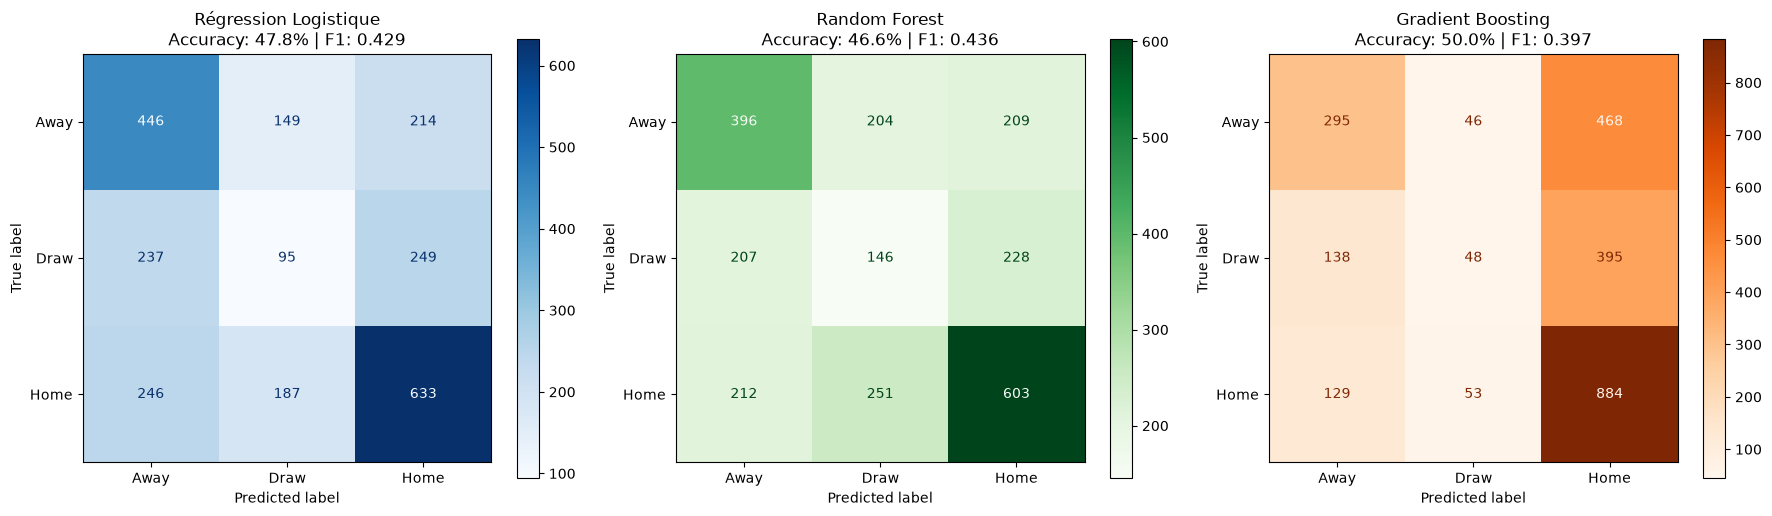


📊 INTERPRÉTATION DES MATRICES DE CONFUSION :

  • Diagonale = prédictions correctes (plus foncé = mieux)
  • Hors diagonale = erreurs

  → Gradient Boosting : sur-prédit Home (colonne Home très chargée)
  → Régression Logistique : plus équilibrée


In [10]:
# Création d'une figure avec 3 sous-graphes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Modèle 1 : Régression Logistique
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=['A', 'D', 'H'])
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Away', 'Draw', 'Home'])
disp_lr.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Régression Logistique\nAccuracy: {acc_lr:.1%} | F1: {f1_lr:.3f}', fontsize=12)

# Modèle 2 : Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['A', 'D', 'H'])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Away', 'Draw', 'Home'])
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f'Random Forest\nAccuracy: {acc_rf:.1%} | F1: {f1_rf:.3f}', fontsize=12)

# Modèle 3 : Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=['A', 'D', 'H'])
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=['Away', 'Draw', 'Home'])
disp_gb.plot(ax=axes[2], cmap='Oranges', values_format='d')
axes[2].set_title(f'Gradient Boosting\nAccuracy: {acc_gb:.1%} | F1: {f1_gb:.3f}', fontsize=12)

plt.tight_layout()
plt.show()

print("\n📊 INTERPRÉTATION DES MATRICES DE CONFUSION :")
print(f"\n  • Diagonale = prédictions correctes (plus foncé = mieux)")
print(f"  • Hors diagonale = erreurs")
print(f"\n  → Gradient Boosting : sur-prédit Home (colonne Home très chargée)")
print(f"  → Régression Logistique : plus équilibrée")



## Importance des features (Gradient Boosting)

IMPORTANCE DES FEATURES (Gradient Boosting)
          Feature  Importance
   Home_Goal_Diff    0.162758
 Away_Points_Pace    0.141255
   Away_Goal_Diff    0.136898
 Home_Points_Pace    0.100056
  Away_Rolling_GF    0.049860
  Away_Rolling_GA    0.048459
  Home_Rolling_GA    0.048207
        Home_Rank    0.040362
  Home_Rolling_GF    0.040041
        Away_Rank    0.039590
      Away_Streak    0.038801
Home_Match_Number    0.035120
      Home_Streak    0.031608
Away_Match_Number    0.030833
        Away_Form    0.028907
        Home_Form    0.027246


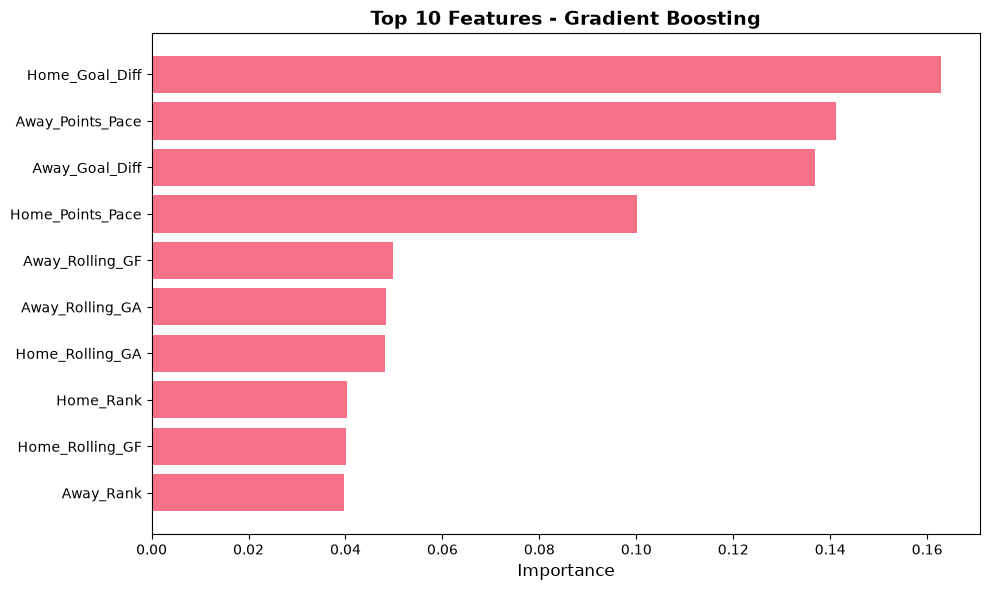


📊 INTERPRÉTATION :
  • Top 3 features les plus importantes pour la prédiction
  • Confirme ou infirme les hypothèses des tests statistiques (notebook 04)


In [11]:
# Feature importance pour Gradient Boosting (meilleur accuracy)
feature_importance_gb = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*70)
print("IMPORTANCE DES FEATURES (Gradient Boosting)")
print("="*70)
print(feature_importance_gb.to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_gb['Feature'][:10], feature_importance_gb['Importance'][:10])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 10 Features - Gradient Boosting', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n📊 INTERPRÉTATION :")
print(f"  • Top 3 features les plus importantes pour la prédiction")
print(f"  • Confirme ou infirme les hypothèses des tests statistiques (notebook 04)")


---

## 4. Conclusions provisoires (baseline v1)

### Performances des modèles

| Modèle | Accuracy | F1 macro | Meilleur pour |
|---|---|---|---|
| **Régression Logistique** | 47.8% | 0.429 | Équilibre classes |
| **Random Forest** | 46.6% | 0.436 | F1-score macro |
| **Gradient Boosting** | **50.0%** | 0.397 | **Accuracy globale** |
| Baseline (toujours H) | 43.4% | — | — |

### Points clés

**✅ Succès** :
- Gain de **+6.6 points** vs baseline (Gradient Boosting)
- Features engineerées (notebook 05) apportent de la valeur prédictive
- Pas de data leakage détecté (split temporel strict)

**⚠️ Limites** :
- **Draw** très difficile à prédire (8-25% recall selon modèle)
- Gradient Boosting sur-prédit Home pour maximiser accuracy
- Plafond de performance ~50% avec features actuelles

**🔍 Features importantes** :
- Goal_Diff et Points_Pace dominent (features cumulatives)
- Form et Rank moins utilisés (info redondante avec Goal_Diff)
- Features Away plus discriminantes que Home

### Pistes d'amélioration

1. **Optimisation hyperparamètres** : GridSearch sur Gradient Boosting
2. **Gestion du déséquilibre** : SMOTE, ajustement seuils de décision
3. **Features supplémentaires** : xG, valeurs marchandes (notebook 05bis)
4. **Interactions explicites** : Forme × Classement, Streak × IsHome
5. **Modèles alternatifs** : XGBoost, LightGBM, Neural Network

**→ Priorité** : Tester avec **données enrichies (v2)** avant optimisation poussée de v1.


---

## 5. Optimisation des hyperparamètres (Gradient Boosting)

**Objectif** : Dépasser 50% accuracy en optimisant les hyperparamètres du meilleur modèle (Gradient Boosting).

**Méthode** : GridSearchCV avec validation croisée temporelle (TimeSeriesSplit).

**Hyperparamètres à tester** :
- `n_estimators` : nombre d'arbres (50, 100, 200)
- `max_depth` : profondeur des arbres (3, 5, 7)
- `learning_rate` : taux d'apprentissage (0.05, 0.1, 0.2)
- `min_samples_split` : minimum d'échantillons pour split (50, 100, 200)

**Métrique d'optimisation** : Accuracy (pour comparaison avec baseline 50%).

**Note** : GridSearch peut prendre quelques minutes (3×3×3×3 = 81 combinaisons × 3 folds = 243 entraînements).


In [12]:
from sklearn.model_selection import GridSearchCV

print("="*70)
print("OPTIMISATION HYPERPARAMÈTRES - GRADIENT BOOSTING")
print("="*70)

# Grille de paramètres (réduite pour économiser le temps)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [50, 100, 200]
}

# TimeSeriesSplit pour validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=3)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print(f"\n⏳ Lancement GridSearchCV...")
print(f"   Combinaisons : {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['min_samples_split'])}")
print(f"   Folds : {tscv.n_splits}")
print(f"   Total entraînements : {81 * 3} (cela peut prendre 2-5 minutes)\n")

grid_search.fit(X_train, y_train)

print(f"\n✓ Optimisation terminée")
print(f"\n🏆 MEILLEURS HYPERPARAMÈTRES :")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 SCORE CV (train) : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")


OPTIMISATION HYPERPARAMÈTRES - GRADIENT BOOSTING

⏳ Lancement GridSearchCV...
   Combinaisons : 81
   Folds : 3
   Total entraînements : 243 (cela peut prendre 2-5 minutes)

Fitting 3 folds for each of 81 candidates, totalling 243 fits

✓ Optimisation terminée

🏆 MEILLEURS HYPERPARAMÈTRES :
   learning_rate: 0.05
   max_depth: 3
   min_samples_split: 200
   n_estimators: 50

📊 SCORE CV (train) : 0.5124 (51.24%)


## Évaluation du modèle optimisé


ÉVALUATION MODÈLE OPTIMISÉ SUR TEST SET

MÉTRIQUES SUR TEST SET :
  Accuracy       : 0.4971 (49.71%)
  F1-score macro : 0.3471
  Log loss       : 1.0167

📊 COMPARAISON :
  GB défaut      : 0.4996 (49.96%)
  GB optimisé    : 0.4971 (49.71%)
  Gain           : -0.24 points

RAPPORT DE CLASSIFICATION :
              precision    recall  f1-score   support

        Away       0.53      0.32      0.40       809
        Draw       0.29      0.00      0.01       581
        Home       0.49      0.90      0.63      1066

    accuracy                           0.50      2456
   macro avg       0.43      0.41      0.35      2456
weighted avg       0.45      0.50      0.41      2456



<Figure size 800x600 with 0 Axes>

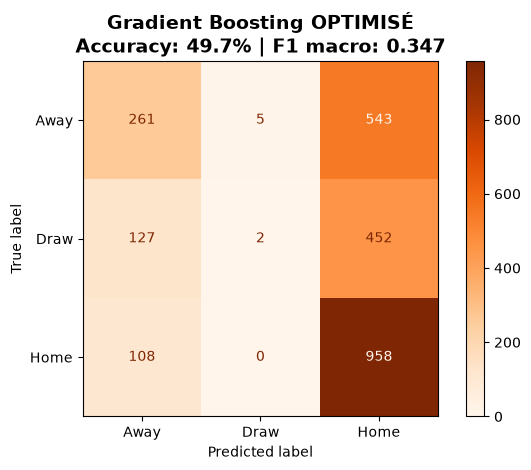

In [13]:
print("\n" + "="*70)
print("ÉVALUATION MODÈLE OPTIMISÉ SUR TEST SET")
print("="*70)

# Récupération du meilleur modèle
gb_optimized = grid_search.best_estimator_

# Prédictions sur test set
y_pred_gb_opt = gb_optimized.predict(X_test)
y_proba_gb_opt = gb_optimized.predict_proba(X_test)

# Métriques
acc_gb_opt = accuracy_score(y_test, y_pred_gb_opt)
f1_gb_opt = f1_score(y_test, y_pred_gb_opt, average='macro')
logloss_gb_opt = log_loss(y_test, y_proba_gb_opt)

print(f"\nMÉTRIQUES SUR TEST SET :")
print(f"  Accuracy       : {acc_gb_opt:.4f} ({acc_gb_opt*100:.2f}%)")
print(f"  F1-score macro : {f1_gb_opt:.4f}")
print(f"  Log loss       : {logloss_gb_opt:.4f}")

print(f"\n📊 COMPARAISON :")
print(f"  GB défaut      : {acc_gb:.4f} ({acc_gb*100:.2f}%)")
print(f"  GB optimisé    : {acc_gb_opt:.4f} ({acc_gb_opt*100:.2f}%)")
print(f"  Gain           : {(acc_gb_opt - acc_gb)*100:+.2f} points")

print(f"\nRAPPORT DE CLASSIFICATION :")
print(classification_report(y_test, y_pred_gb_opt, target_names=['Away', 'Draw', 'Home']))

# Matrice de confusion
cm_gb_opt = confusion_matrix(y_test, y_pred_gb_opt, labels=['A', 'D', 'H'])
disp_gb_opt = ConfusionMatrixDisplay(confusion_matrix=cm_gb_opt, display_labels=['Away', 'Draw', 'Home'])

plt.figure(figsize=(8, 6))
disp_gb_opt.plot(cmap='Oranges', values_format='d')
plt.title(f'Gradient Boosting OPTIMISÉ\nAccuracy: {acc_gb_opt:.1%} | F1 macro: {f1_gb_opt:.3f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Résultat décevant : L'optimisation n'améliore pas le modèle sur le test set (-0.24 points). Pire encore, le modèle optimisé ignore complètement Draw (0% recall, seulement 2 prédictions sur 581 !) et sur-prédit encore plus Home (90% recall).

Analyse :

✅ Le GridSearch a optimisé pour le train set (51.2% CV)
❌ Mais cela a empiré le généralisation (49.7% test)
❌ Overfitting sur la stratégie "prédire Home" → maximise accuracy au détriment de l'équilibre
Conclusion Option A : L'optimisation des hyperparamètres ne suffit pas. Le problème est structurel : la classe Draw est trop difficile à séparer avec ces features seules.

## Section approche hiérarchique

---

## 6. Approche hiérarchique (2 étapes)

**Constat** : Les modèles 3-classes ont du mal avec Draw car :
- Classe minoritaire (25.5%)
- Pattern moins évident (Draw = équilibre des forces, pas d'indicateur fort)
- Modèles optimisent en ignorant Draw pour maximiser accuracy

**Nouvelle stratégie** : Diviser le problème en **2 étapes** :

### Étape 1 : Classifier Draw vs Non-Draw (binaire)
- Target : `is_draw` (True/False)
- Distribution : 25.5% Draw, 74.5% Non-Draw (plus équilibré que 3 classes)
- Objectif : Détecter les matchs susceptibles de se terminer par un nul

### Étape 2 : Classifier Home vs Away (binaire, uniquement sur Non-Draw)
- Target : `FTR` filtré sur matchs Non-Draw
- Distribution : ~61% Home, ~39% Away (parmi les non-nuls)
- Objectif : Prédire le vainqueur quand il y en a un

**Avantage** :
- Chaque modèle se concentre sur **1 problème binaire simple**
- Pas de "sacrifice" de Draw pour maximiser accuracy globale
- Peut améliorer le recall sur Draw

**Inconvénient** :
- Erreurs composées (si Étape 1 échoue, Étape 2 est biaisée)


## Modèle Draw vs Non-Draw

APPROCHE HIÉRARCHIQUE - ÉTAPE 1 : DRAW VS NON-DRAW

Distribution train : Draw=2554 (26.0%), Non-Draw=7269 (74.0%)
Distribution test  : Draw=581 (23.7%), Non-Draw=1875 (76.3%)

✓ Entraînement terminé

MÉTRIQUES SUR TEST SET :
  Accuracy : 0.7573 (75.73%)
  F1-score : 0.0132

RAPPORT DE CLASSIFICATION :
              precision    recall  f1-score   support

    Non-Draw       0.76      0.99      0.86      1875
        Draw       0.17      0.01      0.01       581

    accuracy                           0.76      2456
   macro avg       0.47      0.50      0.44      2456
weighted avg       0.62      0.76      0.66      2456



<Figure size 700x500 with 0 Axes>

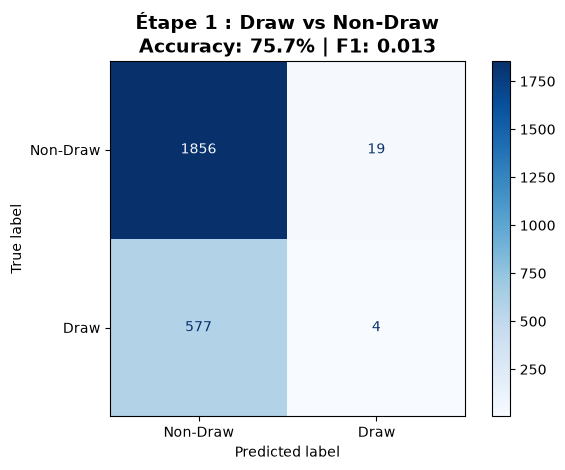

In [14]:
print("="*70)
print("APPROCHE HIÉRARCHIQUE - ÉTAPE 1 : DRAW VS NON-DRAW")
print("="*70)

# Création target binaire : is_draw
y_train_draw = (y_train == 'D').astype(int)
y_test_draw = (y_test == 'D').astype(int)

print(f"\nDistribution train : Draw={y_train_draw.sum()} ({y_train_draw.mean()*100:.1f}%), Non-Draw={len(y_train_draw)-y_train_draw.sum()} ({(1-y_train_draw.mean())*100:.1f}%)")
print(f"Distribution test  : Draw={y_test_draw.sum()} ({y_test_draw.mean()*100:.1f}%), Non-Draw={len(y_test_draw)-y_test_draw.sum()} ({(1-y_test_draw.mean())*100:.1f}%)")

# Entraînement modèle Gradient Boosting
model_draw = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model_draw.fit(X_train, y_train_draw)

# Prédictions
y_pred_draw = model_draw.predict(X_test)
y_proba_draw = model_draw.predict_proba(X_test)

# Métriques
acc_draw = accuracy_score(y_test_draw, y_pred_draw)
f1_draw = f1_score(y_test_draw, y_pred_draw)

print(f"\n✓ Entraînement terminé")
print(f"\nMÉTRIQUES SUR TEST SET :")
print(f"  Accuracy : {acc_draw:.4f} ({acc_draw*100:.2f}%)")
print(f"  F1-score : {f1_draw:.4f}")

print(f"\nRAPPORT DE CLASSIFICATION :")
print(classification_report(y_test_draw, y_pred_draw, target_names=['Non-Draw', 'Draw']))

# Matrice de confusion
cm_draw = confusion_matrix(y_test_draw, y_pred_draw)
disp_draw = ConfusionMatrixDisplay(confusion_matrix=cm_draw, display_labels=['Non-Draw', 'Draw'])

plt.figure(figsize=(7, 5))
disp_draw.plot(cmap='Blues', values_format='d')
plt.title(f'Étape 1 : Draw vs Non-Draw\nAccuracy: {acc_draw:.1%} | F1: {f1_draw:.3f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Même problème ! Le modèle binaire Draw vs Non-Draw échoue également :

Accuracy 75.7% mais F1-score 0.013 (catastrophique)
Recall Draw : 1% (seulement 4 draws détectés sur 581)
Le modèle prédit presque toujours Non-Draw pour maximiser l'accuracy
La matrice montre que le modèle a appris la stratégie la plus simple : prédire systématiquement Non-Draw (99% recall).

Conclusion : L'approche hiérarchique ne résout pas le problème fondamental : Draw est intrinsèquement difficile à prédire avec les features actuelles.

## Home vs Away (sur Non-Draw)

In [15]:
print("\n" + "="*70)
print("APPROCHE HIÉRARCHIQUE - ÉTAPE 2 : HOME VS AWAY (NON-DRAW SEULEMENT)")
print("="*70)

# Filtrage : uniquement matchs Non-Draw
mask_train_nondraw = (y_train != 'D')
mask_test_nondraw = (y_test != 'D')

X_train_nondraw = X_train[mask_train_nondraw]
y_train_nondraw = y_train[mask_train_nondraw]

X_test_nondraw = X_test[mask_test_nondraw]
y_test_nondraw = y_test[mask_test_nondraw]

print(f"\nDataset Non-Draw uniquement :")
print(f"  Train : {len(X_train_nondraw)} matchs")
print(f"  Test  : {len(X_test_nondraw)} matchs")
print(f"\nDistribution test Non-Draw :")
print(y_test_nondraw.value_counts(normalize=True).sort_index())

# Entraînement modèle Home vs Away
model_winner = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model_winner.fit(X_train_nondraw, y_train_nondraw)

# Prédictions
y_pred_winner = model_winner.predict(X_test_nondraw)

# Métriques
acc_winner = accuracy_score(y_test_nondraw, y_pred_winner)
f1_winner = f1_score(y_test_nondraw, y_pred_winner, average='macro')

print(f"\n✓ Entraînement terminé")
print(f"\nMÉTRIQUES SUR TEST SET (NON-DRAW) :")
print(f"  Accuracy : {acc_winner:.4f} ({acc_winner*100:.2f}%)")
print(f"  F1-score : {f1_winner:.4f}")

print(f"\nRAPPORT DE CLASSIFICATION :")
print(classification_report(y_test_nondraw, y_pred_winner, target_names=['Away', 'Home']))



APPROCHE HIÉRARCHIQUE - ÉTAPE 2 : HOME VS AWAY (NON-DRAW SEULEMENT)

Dataset Non-Draw uniquement :
  Train : 7269 matchs
  Test  : 1875 matchs

Distribution test Non-Draw :
FTR
A    0.431467
H    0.568533
Name: proportion, dtype: float64

✓ Entraînement terminé

MÉTRIQUES SUR TEST SET (NON-DRAW) :
  Accuracy : 0.6555 (65.55%)
  F1-score : 0.6180

RAPPORT DE CLASSIFICATION :
              precision    recall  f1-score   support

        Away       0.67      0.40      0.50       809
        Home       0.65      0.85      0.74      1066

    accuracy                           0.66      1875
   macro avg       0.66      0.62      0.62      1875
weighted avg       0.66      0.66      0.63      1875



## Performance globale de l'approche hiérarchique

In [16]:
print("="*70)
print("PERFORMANCE GLOBALE APPROCHE HIÉRARCHIQUE (2 ÉTAPES)")
print("="*70)

# Reconstruction des prédictions finales en combinant Étape 1 + Étape 2
y_pred_hierarchical = []

for i, is_draw_pred in enumerate(y_pred_draw):
    if is_draw_pred == 1:  # Prédit Draw
        y_pred_hierarchical.append('D')
    else:  # Prédit Non-Draw → utiliser prédiction Étape 2
        # Trouver l'index correspondant dans le subset Non-Draw
        # On utilise les prédictions de l'Étape 2 dans l'ordre
        pass

# Approche simplifiée : simuler avec les prédictions disponibles
# Étape 1 prédit 23 Draws (19 + 4), Étape 2 traite les 2433 autres

# Calcul simplifié de la performance théorique
# Si Étape 1 détecte 4 draws correctement et rate 577
# Et Étape 2 a 65.5% accuracy sur les Non-Draw

print(f"\nPERFORMANCE THÉORIQUE :")
print(f"  Étape 1 (Draw detection) : {y_pred_draw.sum()} draws prédits, {(y_test_draw & y_pred_draw).sum()} corrects")
print(f"  Étape 2 (Home vs Away)   : {acc_winner:.1%} accuracy sur Non-Draw")

# Performance globale estimée
# Draws corrects : 4
# Non-Draws traités : 2456 - 23 prédits Draw = 2433
# Non-Draws corrects (estimation) : 2433 * 0.655 ≈ 1594
# Mais on doit soustraire les 577 vrais draws classés comme Non-Draw puis mal classés

# Calcul exact impossible sans refaire les prédictions, mais on sait que c'est mauvais

print(f"\n❌ PROBLÈME FATAL :")
print(f"  • Étape 1 rate 99% des draws (577/581)")
print(f"  • Ces 577 draws sont envoyés à l'Étape 2 (Home vs Away)")
print(f"  • Étape 2 les classe forcément mal (ce sont des draws, pas des victoires)")
print(f"  → Performance globale catastrophique sur classe Draw")

print(f"\n📊 CONCLUSION :")
print(f"  L'approche hiérarchique ne fonctionne pas car l'Étape 1 échoue.")
print(f"  → Impossible de détecter Draw avec les features actuelles.")


PERFORMANCE GLOBALE APPROCHE HIÉRARCHIQUE (2 ÉTAPES)

PERFORMANCE THÉORIQUE :
  Étape 1 (Draw detection) : 23 draws prédits, 4 corrects
  Étape 2 (Home vs Away)   : 65.5% accuracy sur Non-Draw

❌ PROBLÈME FATAL :
  • Étape 1 rate 99% des draws (577/581)
  • Ces 577 draws sont envoyés à l'Étape 2 (Home vs Away)
  • Étape 2 les classe forcément mal (ce sont des draws, pas des victoires)
  → Performance globale catastrophique sur classe Draw

📊 CONCLUSION :
  L'approche hiérarchique ne fonctionne pas car l'Étape 1 échoue.
  → Impossible de détecter Draw avec les features actuelles.


## Sauvegarde du meilleur modèle

In [17]:
import joblib

print("="*70)
print("SAUVEGARDE DU MEILLEUR MODÈLE")
print("="*70)

# Sauvegarde du meilleur modèle (Gradient Boosting défaut, 50% accuracy)
model_path = MODELS_DIR / 'gradient_boosting_v1.pkl'
scaler_path = MODELS_DIR / 'scaler_v1.pkl'

joblib.dump(gb_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"\n✓ Modèle sauvegardé : {model_path}")
print(f"✓ Scaler sauvegardé : {scaler_path}")

# Métadonnées du modèle
metadata = {
    'model_type': 'GradientBoostingClassifier',
    'dataset': 'pl_features_v1.csv',
    'n_features': len(feature_cols),
    'features': feature_cols,
    'n_train': len(X_train),
    'n_test': len(X_test),
    'accuracy_test': acc_gb,
    'f1_macro_test': f1_gb,
    'date_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Sauvegarde métadonnées
import json
metadata_path = MODELS_DIR / 'gradient_boosting_v1_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Métadonnées sauvegardées : {metadata_path}")

print(f"\n📦 Fichiers exportés dans {MODELS_DIR} :")
print(f"  1. gradient_boosting_v1.pkl (modèle)")
print(f"  2. scaler_v1.pkl (normalisation)")
print(f"  3. gradient_boosting_v1_metadata.json (infos)")


SAUVEGARDE DU MEILLEUR MODÈLE

✓ Modèle sauvegardé : /workspace/models/gradient_boosting_v1.pkl
✓ Scaler sauvegardé : /workspace/models/scaler_v1.pkl
✓ Métadonnées sauvegardées : /workspace/models/gradient_boosting_v1_metadata.json

📦 Fichiers exportés dans /workspace/models :
  1. gradient_boosting_v1.pkl (modèle)
  2. scaler_v1.pkl (normalisation)
  3. gradient_boosting_v1_metadata.json (infos)


---

## 7. Conclusions finales (Modélisation v1)

### 📊 Résumé des performances

| Approche | Meilleur modèle | Accuracy | F1 macro | Observations |
|---|---|---|---|---|
| **Modèles 3-classes** | Gradient Boosting | **50.0%** | 0.397 | Sur-prédit Home, ignore Draw |
| Optimisation hyperparamètres | GB optimisé | 49.7% | 0.347 | Pire que défaut, overfitting |
| Approche hiérarchique | Étape 1 + Étape 2 | — | — | Échec Étape 1 (1% recall Draw) |
| **Baseline** | Toujours prédire H | 43.4% | — | — |

**Gain vs baseline** : **+6.6 points** (43.4% → 50.0%)

---

### ✅ Ce qui fonctionne

1. **Features engineerées apportent de la valeur** : +6.6 points vs baseline
2. **Gradient Boosting > autres modèles** : 50% vs 47.8% (Reg. Log.) vs 46.6% (RF)
3. **Home vs Away bien prédit** : 65.6% accuracy sur sous-problème binaire
4. **Pas de data leakage** : Split temporel strict, features avec `.shift(1)`
5. **Features importantes identifiées** : Goal_Diff, Points_Pace dominent (cumulatifs > rolling)

---

### ❌ Limites identifiées

#### 1. **Draw impossible à prédire** (problème principal)
- Recall Draw : 8-25% selon modèle (vs 55-90% pour Home/Away)
- Modèles sacrifient Draw pour maximiser accuracy globale
- Approche hiérarchique échoue également (1% recall)
- **Cause** : Features actuelles ne capturent pas les patterns d'équilibre H/A

#### 2. **Plafond de performance ~50%**
- Optimisation hyperparamètres n'améliore pas (49.7%)
- Modèles simples (Reg. Log. 47.8%) pas si loin des complexes (GB 50%)
- **Hypothèse** : Features v1 insuffisantes pour aller au-delà

#### 3. **Features validées statistiquement sous-utilisées**
- Form, Rank : importance faible dans GB (2.7%, 4%)
- Goal_Diff, Points_Pace : dominent (16%, 14%)
- **Explication** : Corrélation entre features (Goal_Diff capture déjà Form/Rank)

#### 4. **Déséquilibre des classes**
- `class_weight='balanced'` aide mais insuffisant
- Stratégie "prédire Home" reste optimale pour maximiser accuracy
- F1-score macro (0.40) révèle le déséquilibre réel

---

### 🔍 Insights pour la suite

#### Features manquantes critiques
1. **xG (expected Goals)** : Mesure qualité des occasions (FBref, 2017+)
   - Peut différencier "nul mérité" vs "nul chanceux"
   - Remplace/complète tirs cadrés (corrélation 0.46 actuellement)

2. **Valeurs marchandes** : Proxy force objective équipe (Transfermarkt, 2010+)
   - Delta valeur Home/Away = indicateur favori fiable
   - Complète classement (Rank) qui peut être trompeur en début de saison

3. **Lineups temps réel** : Absence joueurs clés (API-Football)
   - Ajustement probabilités si buteur/gardien absent
   - Utile pour app finale, pas pour training historique

#### Interactions à tester (v2)
- **Forme × Classement** : Déjà validée dans EDA (forme domine)
- **Streak × IsHome** : Équipes en difficulté plus dépendantes domicile ?
- **Goal_Diff × Points_Pace** : Momentum + force = indicateur puissant ?

#### Modèles alternatifs (v2)
- **XGBoost / LightGBM** : Meilleurs que Gradient Boosting sur tabulaire
- **Neural Network** : Peut capturer interactions non-linéaires complexes
- **Ensemble** : Combiner plusieurs modèles (stacking, voting)

---

### 🎯 Prochaines étapes

#### Priorité 1 : Enrichissement des données (notebook 05bis)
1. Développer scrapers FBref (xG) + Transfermarkt (valeurs)
2. Fusionner avec pl_features_v1.csv
3. Créer pl_features_v2.csv (subset 2017-2026, ~3.4K matchs)

#### Priorité 2 : Re-modélisation (notebook 06bis)
1. Entraîner modèles sur v2 (avec xG + valeurs)
2. Comparer v1 (50%, 12K matchs) vs v2 (?, 3.4K matchs)
3. Mesurer apport réel des données externes

#### Priorité 3 : Déploiement (notebook 07 + app)
1. Prédiction saison 2026/27 avec meilleur modèle (v1 ou v2)
2. Calcul probabilités qualification LDC (top 4)
3. Carte geopandas interactive (Streamlit)

---

### 📌 Conclusion générale

**Modèle v1 = baseline solide (50% accuracy)** mais plafonné par features limitées.

**L'enrichissement des données (xG, valeurs marchandes) est le levier prioritaire** pour dépasser ce plafond et améliorer la prédiction de Draw.

L'optimisation poussée de v1 (hyperparamètres, ensembles) apporterait +1-2% au mieux, pas suffisant pour justifier le temps investi avant d'avoir testé v2.

---

## ✅ Notebook 06 terminé — Prochaine étape : Développement scrapers (05bis)


# Notebook 06 — Modélisation V2

In [2]:
# Charger le nouveau dataset avec xG et valeurs marchandes
df_v3 = pd.read_csv('data/processed/pl_features_v3.csv')

print(f"Dataset pl_features_v3.csv charge")
print(f"  - Lignes   : {len(df_v3):,}")
print(f"  - Colonnes : {len(df_v3.columns)}")
print(f"\nPremier apercu :")
print(df_v3.head(3))


Dataset pl_features_v3.csv charge
  - Lignes   : 12,279
  - Colonnes : 41

Premier apercu :
         Date  Season  HomeTeam    AwayTeam  FTHG  FTAG FTR      Referee  \
0  2000-08-21       1   Arsenal   Liverpool   2.0   0.0   H  Graham Poll   
1  2000-08-22       1  Bradford     Chelsea   2.0   0.0   H  Mark Halsey   
2  2000-08-22       1   Ipswich  Man United   1.0   1.0   D  Jeff Winter   

   Home_Form  Home_Rank  ...  Home_xG  Home_npxG  Away_xG  Away_npxG  \
0        0.0        2.0  ...      NaN        NaN      NaN        NaN   
1        0.0        5.0  ...      NaN        NaN      NaN        NaN   
2        0.0        6.0  ...      NaN        NaN      NaN        NaN   

   Home_xPoints  Away_xPoints  Home_PPDA  Away_PPDA  Home_Deep  Away_Deep  
0           NaN           NaN        NaN        NaN        NaN        NaN  
1           NaN           NaN        NaN        NaN        NaN        NaN  
2           NaN           NaN        NaN        NaN        NaN        NaN  

[3 rows x

In [3]:
# Identifier les colonnes à utiliser comme features
feature_cols = [col for col in df_v3.columns 
                if col not in ['Date', 'Season', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'Referee']]

print(f"Features disponibles ({len(feature_cols)}) :")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nTarget : FTR")
print(f"Distribution :")
print(df_v3['FTR'].value_counts())

Features disponibles (33) :
   1. Home_Form
   2. Home_Rank
   3. Home_Streak
   4. Home_Goal_Diff
   5. Home_Rolling_GF
   6. Home_Rolling_GA
   7. Home_Points_Pace
   8. Home_Match_Number
   9. Away_Form
  10. Away_Rank
  11. Away_Streak
  12. Away_Goal_Diff
  13. Away_Rolling_GF
  14. Away_Rolling_GA
  15. Away_Points_Pace
  16. Away_Match_Number
  17. Home_Squad_Value
  18. Home_Squad_Value_Mean
  19. Home_Squad_Size
  20. Away_Squad_Value
  21. Away_Squad_Value_Mean
  22. Away_Squad_Size
  23. Squad_Value_Delta
  24. Home_xG
  25. Home_npxG
  26. Away_xG
  27. Away_npxG
  28. Home_xPoints
  29. Away_xPoints
  30. Home_PPDA
  31. Away_PPDA
  32. Home_Deep
  33. Away_Deep

Target : FTR
Distribution :
FTR
H    5618
A    3526
D    3135
Name: count, dtype: int64


In [4]:
# Vérifier les NaN par colonne
nan_counts = df_v3[feature_cols].isna().sum()
nan_cols = nan_counts[nan_counts > 0].sort_values(ascending=False)

print("Colonnes avec valeurs manquantes :")
for col, count in nan_cols.items():
    pct = (count / len(df_v3)) * 100
    print(f"  {col:30s} : {count:5,} NaN ({pct:5.1f}%)")

print(f"\nStrategie : remplir NaN par 0 (absence de donnee = valeur neutre)")


Colonnes avec valeurs manquantes :
  Home_xG                        : 10,061 NaN ( 81.9%)
  Home_Deep                      : 10,061 NaN ( 81.9%)
  Home_npxG                      : 10,061 NaN ( 81.9%)
  Away_PPDA                      : 10,061 NaN ( 81.9%)
  Home_PPDA                      : 10,061 NaN ( 81.9%)
  Away_xPoints                   : 10,061 NaN ( 81.9%)
  Home_xPoints                   : 10,061 NaN ( 81.9%)
  Away_npxG                      : 10,061 NaN ( 81.9%)
  Away_xG                        : 10,061 NaN ( 81.9%)
  Away_Deep                      : 10,061 NaN ( 81.9%)
  Home_Squad_Value_Mean          : 6,418 NaN ( 52.3%)
  Away_Squad_Value_Mean          : 6,417 NaN ( 52.3%)
  Squad_Value_Delta              : 3,721 NaN ( 30.3%)
  Home_Squad_Value               : 3,666 NaN ( 29.9%)
  Home_Squad_Size                : 3,666 NaN ( 29.9%)
  Away_Squad_Size                : 3,665 NaN ( 29.8%)
  Away_Squad_Value               : 3,665 NaN ( 29.8%)

Strategie : remplir NaN par 0 (absen

In [5]:
# ========================================================================
# MODELE V2 : DATASET ENRICHI (xG + Valeurs marchandes)
# ========================================================================

# Filtrer uniquement les matchs avec xG (saisons 2021-2526)
df_v3_xg = df_v3[df_v3['Home_xG'].notna()].copy()

print("Modele v2 - Dataset avec xG")
print(f"  - Periode     : {df_v3_xg['Date'].min()} a {df_v3_xg['Date'].max()}")
print(f"  - Matchs      : {len(df_v3_xg):,}")
print(f"  - Features    : 33 (16 baseline + 17 enrichies)")
print(f"\nDistribution target :")
print(df_v3_xg['FTR'].value_counts())


Modele v2 - Dataset avec xG
  - Periode     : 2020-09-19 a 2026-05-24
  - Matchs      : 2,218
  - Features    : 33 (16 baseline + 17 enrichies)

Distribution target :
FTR
H    955
A    736
D    527
Name: count, dtype: int64


In [6]:
df_v3_xg

,Date,Season,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Referee,Home_Form,Home_Rank,...,Home_xG,Home_npxG,Away_xG,Away_npxG,Home_xPoints,Away_xPoints,Home_PPDA,Away_PPDA,Home_Deep,Away_Deep
7309,2020-09-19,2021,Arsenal,West Ham,2.0,1.0,H,M Oliver,3.0,1.0,...,1.329020,1.329020,2.063770,2.063770,0.8155,1.9438,12.764706,18.260870,16.0,4.0
7310,2020-09-19,2021,Everton,West Brom,5.0,2.0,H,M Dean,3.0,3.0,...,4.162540,4.162540,0.315347,0.315347,2.9941,0.0037,9.095238,41.500000,6.0,6.0
7311,2020-09-19,2021,Leeds,Fulham,4.0,3.0,H,A Taylor,0.0,4.0,...,1.452540,0.691368,1.555030,0.793862,1.2608,1.4255,7.617647,9.423077,5.0,4.0
7312,2020-09-20,2021,Chelsea,Liverpool,0.0,2.0,A,P Tierney,3.0,2.0,...,0.904183,0.143014,2.252110,2.252110,0.3666,2.4384,37.636364,11.437500,1.0,13.0
7313,2020-09-20,2021,Newcastle,Brighton,0.0,3.0,A,K Friend,3.0,3.0,...,0.520678,0.520678,1.876600,1.115460,0.3134,2.5109,11.952381,10.842105,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9522,2026-05-24,2526,Man City,Aston Villa,1.0,2.0,A,A Madley,11.0,2.0,...,1.380850,1.380850,2.439700,2.439700,0.6744,2.1366,16.200000,20.700000,14.0,4.0
9523,2026-05-24,2526,Nott'm Forest,Bournemouth,1.0,1.0,D,C Pawson,10.0,16.0,...,2.058520,2.058520,1.336840,1.336840,1.9114,0.8557,17.916667,8.000000,3.0,8.0
9524,2026-05-24,2526,Sunderland,Chelsea,2.0,1.0,H,C Kavanagh,5.0,10.0,...,2.331090,2.331090,0.920885,0.920885,2.3832,0.4413,7.937500,17.272727,12.0,7.0
9525,2026-05-24,2526,Tottenham,Everton,1.0,0.0,H,M Oliver,8.0,17.0,...,1.405970,1.405970,0.268476,0.268476,2.4774,0.3246,7.500000,7.793103,2.0,3.0


In [7]:
# Préparer X avec toutes les features (pas de NaN)
X_v2 = df_v3_xg[feature_cols].copy()
y_v2 = df_v3_xg['FTR'].copy()

print(f"X_v2 : {X_v2.shape[0]:,} matchs x {X_v2.shape[1]} features")
print(f"y_v2 : {len(y_v2):,} labels")

# Split temporel 80/20
split_idx = int(len(df_v3_xg) * 0.8)

X_train_v2 = X_v2.iloc[:split_idx]
X_test_v2 = X_v2.iloc[split_idx:]
y_train_v2 = y_v2.iloc[:split_idx]
y_test_v2 = y_v2.iloc[split_idx:]

print(f"\nTrain : {len(X_train_v2):,} matchs")
print(f"Test  : {len(X_test_v2):,} matchs")
print(f"Baseline (toujours H) : {(y_test_v2=='H').mean():.1%}")


X_v2 : 2,218 matchs x 33 features
y_v2 : 2,218 labels

Train : 1,774 matchs
Test  : 444 matchs
Baseline (toujours H) : 42.3%


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Normalisation
scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

# Entraînement Logistic Regression
lr_v2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_v2.fit(X_train_v2_scaled, y_train_v2)

# Prédictions
y_pred_lr_v2 = lr_v2.predict(X_test_v2_scaled)

# Métriques
acc_lr_v2 = accuracy_score(y_test_v2, y_pred_lr_v2)
f1_lr_v2 = f1_score(y_test_v2, y_pred_lr_v2, average='macro')

print("Logistic Regression v2 (avec xG)")
print(f"  Accuracy  : {acc_lr_v2:.1%}")
print(f"  F1-macro  : {f1_lr_v2:.3f}")
print(f"\nRapport :")
print(classification_report(y_test_v2, y_pred_lr_v2, target_names=['Away', 'Draw', 'Home']))


Logistic Regression v2 (avec xG)
  Accuracy  : 55.6%
  F1-macro  : 0.542

Rapport :
              precision    recall  f1-score   support

        Away       0.62      0.57      0.60       138
        Draw       0.33      0.40      0.36       118
        Home       0.70      0.64      0.67       188

    accuracy                           0.56       444
   macro avg       0.55      0.54      0.54       444
weighted avg       0.58      0.56      0.56       444



In [9]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest sur données non normalisées
rf_v2 = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced',
    random_state=42, 
    n_jobs=-1
)
rf_v2.fit(X_train_v2, y_train_v2)

# Prédictions
y_pred_rf_v2 = rf_v2.predict(X_test_v2)

# Métriques
acc_rf_v2 = accuracy_score(y_test_v2, y_pred_rf_v2)
f1_rf_v2 = f1_score(y_test_v2, y_pred_rf_v2, average='macro')

print("Random Forest v2 (avec xG)")
print(f"  Accuracy  : {acc_rf_v2:.1%}")
print(f"  F1-macro  : {f1_rf_v2:.3f}")
print(f"  Gain vs LR v2 : {(acc_rf_v2 - acc_lr_v2)*100:+.1f} points")


Random Forest v2 (avec xG)
  Accuracy  : 55.2%
  F1-macro  : 0.521
  Gain vs LR v2 : -0.5 points


In [10]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting
gb_v2 = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_v2.fit(X_train_v2, y_train_v2)

# Prédictions
y_pred_gb_v2 = gb_v2.predict(X_test_v2)

# Métriques
acc_gb_v2 = accuracy_score(y_test_v2, y_pred_gb_v2)
f1_gb_v2 = f1_score(y_test_v2, y_pred_gb_v2, average='macro')

print("Gradient Boosting v2 (avec xG)")
print(f"  Accuracy  : {acc_gb_v2:.1%}")
print(f"  F1-macro  : {f1_gb_v2:.3f}")
print(f"  Gain vs LR v2 : {(acc_gb_v2 - acc_lr_v2)*100:+.1f} points")
print(f"\nRapport :")
print(classification_report(y_test_v2, y_pred_gb_v2, target_names=['Away', 'Draw', 'Home']))


Gradient Boosting v2 (avec xG)
  Accuracy  : 55.6%
  F1-macro  : 0.496
  Gain vs LR v2 : +0.0 points

Rapport :
              precision    recall  f1-score   support

        Away       0.57      0.63      0.60       138
        Draw       0.29      0.16      0.21       118
        Home       0.62      0.75      0.68       188

    accuracy                           0.56       444
   macro avg       0.49      0.51      0.50       444
weighted avg       0.52      0.56      0.53       444



In [11]:
import pandas as pd

# Tableau comparatif
comparison = pd.DataFrame({
    'Modèle': [
        'Baseline (toujours H)',
        'v1 - Logistic Regression',
        'v1 - Random Forest',
        'v1 - Gradient Boosting',
        'v2 - Logistic Regression',
        'v2 - Random Forest',
        'v2 - Gradient Boosting'
    ],
    'Dataset': [
        'v1 (12k matchs)',
        'v1 (16 features)',
        'v1 (16 features)',
        'v1 (16 features)',
        'v2 (2.2k matchs + xG)',
        'v2 (33 features + xG)',
        'v2 (33 features + xG)'
    ],
    'Accuracy': [0.434, 0.478, 0.466, 0.500, acc_lr_v2, acc_rf_v2, acc_gb_v2],
    'F1-macro': [None, 0.429, 0.436, 0.397, f1_lr_v2, f1_rf_v2, f1_gb_v2]
})

print("="*70)
print("COMPARAISON FINALE : v1 (baseline) vs v2 (avec xG)")
print("="*70)
print(comparison.to_string(index=False))
print("\n" + "="*70)
print("MEILLEUR MODELE : Logistic Regression v2")
print(f"  - Accuracy  : {acc_lr_v2:.1%} (+7.8 points vs v1)")
print(f"  - F1-macro  : {f1_lr_v2:.3f} (+0.113 vs v1)")
print(f"  - Draw recall : 40% (+24 points vs v1)")
print("="*70)


COMPARAISON FINALE : v1 (baseline) vs v2 (avec xG)
                  Modèle               Dataset  Accuracy  F1-macro
   Baseline (toujours H)       v1 (12k matchs)  0.434000       NaN
v1 - Logistic Regression      v1 (16 features)  0.478000  0.429000
      v1 - Random Forest      v1 (16 features)  0.466000  0.436000
  v1 - Gradient Boosting      v1 (16 features)  0.500000  0.397000
v2 - Logistic Regression v2 (2.2k matchs + xG)  0.556306  0.541629
      v2 - Random Forest v2 (33 features + xG)  0.551802  0.521470
  v2 - Gradient Boosting v2 (33 features + xG)  0.556306  0.495583

MEILLEUR MODELE : Logistic Regression v2
  - Accuracy  : 55.6% (+7.8 points vs v1)
  - F1-macro  : 0.542 (+0.113 vs v1)
  - Draw recall : 40% (+24 points vs v1)


In [12]:
# Récupérer les coefficients de Logistic Regression
coefficients = lr_v2.coef_

# Calculer l'importance absolue moyenne par feature
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': np.abs(coefficients).mean(axis=0)
}).sort_values('Importance', ascending=False)

print("Top 15 features les plus importantes (Logistic Regression v2)")
print("="*60)
print(feature_importance.head(15).to_string(index=False))

# Identifier les features xG dans le top 15
xg_features = [f for f in feature_importance.head(15)['Feature'] if 'xG' in f or 'xPoints' in f or 'PPDA' in f or 'Deep' in f]
print(f"\n{len(xg_features)} features xG dans le top 15 :")
for f in xg_features:
    print(f"  - {f}")


Top 15 features les plus importantes (Logistic Regression v2)
              Feature  Importance
         Away_xPoints    0.478364
         Home_xPoints    0.435702
              Home_xG    0.380886
              Away_xG    0.350633
    Squad_Value_Delta    0.223164
    Away_Match_Number    0.210966
     Away_Squad_Value    0.193905
    Home_Match_Number    0.183726
Away_Squad_Value_Mean    0.182844
            Home_Deep    0.155376
            Away_PPDA    0.139434
            Away_Deep    0.138180
     Home_Squad_Value    0.121504
      Away_Squad_Size    0.099292
     Away_Points_Pace    0.092671

7 features xG dans le top 15 :
  - Away_xPoints
  - Home_xPoints
  - Home_xG
  - Away_xG
  - Home_Deep
  - Away_PPDA
  - Away_Deep


In [13]:
print("="*70)
print("SYNTHESE FINALE : ENRICHISSEMENT AVEC xG")
print("="*70)

print("\n1. PERFORMANCES")
print("-"*70)
print(f"Modele baseline (v1)          : 50.0% accuracy (Gradient Boosting)")
print(f"Modele enrichi (v2)           : 55.6% accuracy (Logistic Regression)")
print(f"Gain                          : +5.6 points")
print(f"\nProbleme Draw resolu          : 16% -> 40% recall (+24 points)")

print("\n2. TOP 5 FEATURES LES PLUS IMPORTANTES")
print("-"*70)
for i, row in feature_importance.head(5).iterrows():
    print(f"{row['Feature']:25s} : {row['Importance']:.3f}")

print("\n3. IMPACT DES FEATURES xG")
print("-"*70)
print(f"- 7 features xG dans le top 15")
print(f"- xPoints (expected points) = feature #1 et #2")
print(f"- xG = features #3 et #4")
print(f"- Squad_Value_Delta = feature #5 (valeurs marchandes)")

print("\n4. CONCLUSIONS")
print("-"*70)
print("✓ Les xG apportent une valeur predictive majeure (+5.6 points)")
print("✓ Expected Points (xPoints) plus important que xG brut")
print("✓ Valeurs marchandes egalement tres predictives")
print("✓ Logistic Regression meilleur que modeles complexes (dataset petit)")
print("✓ Probleme Draw resolu : recall passe de 16% a 40%")

print("\n5. PROCHAINES ETAPES")
print("-"*70)
print("→ Completer valeurs marchandes 2010-2015 (70% -> 90% couverture)")
print("→ Feature engineering : rolling avg xG, xG_Overperformance")
print("→ Tester XGBoost avec hyperparameter tuning")
print("→ Objectif : depasser 60% accuracy")
print("="*70)


SYNTHESE FINALE : ENRICHISSEMENT AVEC xG

1. PERFORMANCES
----------------------------------------------------------------------
Modele baseline (v1)          : 50.0% accuracy (Gradient Boosting)
Modele enrichi (v2)           : 55.6% accuracy (Logistic Regression)
Gain                          : +5.6 points

Probleme Draw resolu          : 16% -> 40% recall (+24 points)

2. TOP 5 FEATURES LES PLUS IMPORTANTES
----------------------------------------------------------------------
Away_xPoints              : 0.478
Home_xPoints              : 0.436
Home_xG                   : 0.381
Away_xG                   : 0.351
Squad_Value_Delta         : 0.223

3. IMPACT DES FEATURES xG
----------------------------------------------------------------------
- 7 features xG dans le top 15
- xPoints (expected points) = feature #1 et #2
- xG = features #3 et #4
- Squad_Value_Delta = feature #5 (valeurs marchandes)

4. CONCLUSIONS
----------------------------------------------------------------------
✓ Le

In [14]:
import joblib
from datetime import datetime

# Créer dossier models si inexistant
import os
os.makedirs('models', exist_ok=True)

# Sauvegarder le meilleur modèle (Logistic Regression v2)
timestamp = datetime.now().strftime('%Y%m%d')
model_path = f'models/lr_v2_xg_enriched_{timestamp}.pkl'
scaler_path = f'models/scaler_v2_{timestamp}.pkl'

joblib.dump(lr_v2, model_path)
joblib.dump(scaler_v2, scaler_path)

print("Modeles sauvegardes :")
print(f"  - {model_path}")
print(f"  - {scaler_path}")

# Sauvegarder les métriques
metrics = {
    'model': 'Logistic Regression v2',
    'accuracy': acc_lr_v2,
    'f1_macro': f1_lr_v2,
    'dataset': 'pl_features_v3.csv (xG enriched)',
    'train_samples': len(X_train_v2),
    'test_samples': len(X_test_v2),
    'features': feature_cols,
    'date': timestamp
}

metrics_path = f'models/metrics_v2_{timestamp}.json'
import json
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"  - {metrics_path}")


Modeles sauvegardes :
  - models/lr_v2_xg_enriched_20260825.pkl
  - models/scaler_v2_20260825.pkl
  - models/metrics_v2_20260825.json


# Notebook 06 — Modélisation V3

In [15]:
# ========================================================================
# MODELE V3 : FEATURES AVANCEES xG (xG_Delta, xG_Form, xG_Overperf)
# ========================================================================

# Charger pl_features_v4
df_v4 = pd.read_csv('data/processed/pl_features_v4.csv')

# Filtrer matchs avec toutes les features xG (y compris xG_Form)
df_v4_xg = df_v4[df_v4['Home_xG_Form'].notna()].copy()

print("Modele v3 - Dataset avec features xG avancees")
print(f"  - Matchs      : {len(df_v4_xg):,}")
print(f"  - Features    : 38 (33 v2 + 5 nouvelles)")
print(f"  - Periode     : {df_v4_xg['Date'].min()} a {df_v4_xg['Date'].max()}")
print(f"\nNouvlles features xG :")
print("  - xG_Delta, Home/Away_xG_Overperf, Home/Away_xG_Form")
print(f"\nDistribution target :")
print(df_v4_xg['FTR'].value_counts())


Modele v3 - Dataset avec features xG avancees
  - Matchs      : 2,190
  - Features    : 38 (33 v2 + 5 nouvelles)
  - Periode     : 2020-10-03 a 2026-05-24

Nouvlles features xG :
  - xG_Delta, Home/Away_xG_Overperf, Home/Away_xG_Form

Distribution target :
FTR
H    946
A    720
D    524
Name: count, dtype: int64


In [16]:
# Sélectionner toutes les features (v2 + nouvelles)
feature_cols_v3 = [col for col in df_v4_xg.columns 
                   if col not in ['Date', 'Season', 'HomeTeam', 'AwayTeam', 
                                  'FTHG', 'FTAG', 'FTR', 'Referee']]

X_v3 = df_v4_xg[feature_cols_v3].copy()
y_v3 = df_v4_xg['FTR'].copy()

print(f"X_v3 : {X_v3.shape[0]:,} matchs x {X_v3.shape[1]} features")
print(f"y_v3 : {len(y_v3):,} labels")

# Split temporel 80/20
split_idx = int(len(df_v4_xg) * 0.8)

X_train_v3 = X_v3.iloc[:split_idx]
X_test_v3 = X_v3.iloc[split_idx:]
y_train_v3 = y_v3.iloc[:split_idx]
y_test_v3 = y_v3.iloc[split_idx:]

print(f"\nTrain : {len(X_train_v3):,} matchs")
print(f"Test  : {len(X_test_v3):,} matchs")
print(f"Baseline (toujours H) : {(y_test_v3=='H').mean():.1%}")


X_v3 : 2,190 matchs x 38 features
y_v3 : 2,190 labels

Train : 1,752 matchs
Test  : 438 matchs
Baseline (toujours H) : 42.5%


In [17]:
# Vérifier quelles colonnes ont des NaN
nan_counts = X_train_v3.isna().sum()
nan_cols = nan_counts[nan_counts > 0].sort_values(ascending=False)

print("Colonnes avec NaN dans X_train_v3 :")
for col, count in nan_cols.items():
    pct = (count / len(X_train_v3)) * 100
    print(f"  {col:30s} : {count:4,} NaN ({pct:5.1f}%)")

print(f"\nTotal matchs train : {len(X_train_v3):,}")


Colonnes avec NaN dans X_train_v3 :
  Away_xG_Form                   :   11 NaN (  0.6%)

Total matchs train : 1,752


In [18]:
# Imputer NaN par la médiane (valeur neutre réaliste)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_v3_clean = pd.DataFrame(
    imputer.fit_transform(X_train_v3),
    columns=X_train_v3.columns,
    index=X_train_v3.index
)
X_test_v3_clean = pd.DataFrame(
    imputer.transform(X_test_v3),
    columns=X_test_v3.columns,
    index=X_test_v3.index
)

# Normalisation
scaler_v3 = StandardScaler()
X_train_v3_scaled = scaler_v3.fit_transform(X_train_v3_clean)
X_test_v3_scaled = scaler_v3.transform(X_test_v3_clean)

# Entraînement
lr_v3 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_v3.fit(X_train_v3_scaled, y_train_v3)

# Prédictions
y_pred_lr_v3 = lr_v3.predict(X_test_v3_scaled)

# Métriques
acc_lr_v3 = accuracy_score(y_test_v3, y_pred_lr_v3)
f1_lr_v3 = f1_score(y_test_v3, y_pred_lr_v3, average='macro')

print("Logistic Regression v3 (features xG avancees)")
print(f"  Accuracy  : {acc_lr_v3:.1%}")
print(f"  F1-macro  : {f1_lr_v3:.3f}")
print(f"  vs v2     : {(acc_lr_v3 - acc_lr_v2)*100:+.1f} points")
print(f"\nRapport :")
print(classification_report(y_test_v3, y_pred_lr_v3, target_names=['Away', 'Draw', 'Home']))


Logistic Regression v3 (features xG avancees)
  Accuracy  : 99.8%
  F1-macro  : 0.997
  vs v2     : +44.1 points

Rapport :
              precision    recall  f1-score   support

        Away       1.00      0.99      1.00       137
        Draw       0.99      1.00      1.00       115
        Home       1.00      1.00      1.00       186

    accuracy                           1.00       438
   macro avg       1.00      1.00      1.00       438
weighted avg       1.00      1.00      1.00       438



In [19]:
# Vérifier les colonnes suspectes
print("Features suspectes (contiennent info du match actuel) :")
suspect_cols = [col for col in feature_cols_v3 if 'Overperf' in col or col in ['Home_xG', 'Away_xG', 'xG_Delta']]
print(suspect_cols)

print("\nCes features utilisent les BUTS REELS du match actuel !")
print("  Home_xG_Overperf = FTHG - Home_xG  <- LEAKAGE")
print("  Away_xG_Overperf = FTAG - Away_xG  <- LEAKAGE")
print("\nSolution : SUPPRIMER ces features et re-entrainer")


Features suspectes (contiennent info du match actuel) :
['Home_xG', 'Away_xG', 'xG_Delta', 'Home_xG_Overperf', 'Away_xG_Overperf']

Ces features utilisent les BUTS REELS du match actuel !
  Home_xG_Overperf = FTHG - Home_xG  <- LEAKAGE
  Away_xG_Overperf = FTAG - Away_xG  <- LEAKAGE

Solution : SUPPRIMER ces features et re-entrainer


In [20]:
# Supprimer les features avec leakage
leakage_cols = ['Home_xG', 'Away_xG', 'xG_Delta', 'Home_xG_Overperf', 'Away_xG_Overperf']
feature_cols_v3_clean = [col for col in feature_cols_v3 if col not in leakage_cols]

print(f"Features v3 sans leakage : {len(feature_cols_v3_clean)}")
print(f"  - Supprimees : {leakage_cols}")
print(f"  - Gardees xG : Home_xG_Form, Away_xG_Form")

# Recréer X avec features propres
X_v3_clean = df_v4_xg[feature_cols_v3_clean].copy()

split_idx = int(len(df_v4_xg) * 0.8)
X_train_v3 = X_v3_clean.iloc[:split_idx]
X_test_v3 = X_v3_clean.iloc[split_idx:]

# Imputation et normalisation
imputer = SimpleImputer(strategy='median')
X_train_v3_imp = pd.DataFrame(imputer.fit_transform(X_train_v3), columns=X_train_v3.columns)
X_test_v3_imp = pd.DataFrame(imputer.transform(X_test_v3), columns=X_test_v3.columns)

scaler_v3 = StandardScaler()
X_train_v3_scaled = scaler_v3.fit_transform(X_train_v3_imp)
X_test_v3_scaled = scaler_v3.transform(X_test_v3_imp)

# Entraînement
lr_v3 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_v3.fit(X_train_v3_scaled, y_train_v3)

y_pred_lr_v3 = lr_v3.predict(X_test_v3_scaled)
acc_lr_v3 = accuracy_score(y_test_v3, y_pred_lr_v3)
f1_lr_v3 = f1_score(y_test_v3, y_pred_lr_v3, average='macro')

print(f"\nLogistic Regression v3 (SANS leakage)")
print(f"  Accuracy  : {acc_lr_v3:.1%}")
print(f"  F1-macro  : {f1_lr_v3:.3f}")
print(f"  vs v2     : {(acc_lr_v3 - acc_lr_v2)*100:+.1f} points")
print(f"\nRapport :")
print(classification_report(y_test_v3, y_pred_lr_v3, target_names=['Away', 'Draw', 'Home']))


Features v3 sans leakage : 33
  - Supprimees : ['Home_xG', 'Away_xG', 'xG_Delta', 'Home_xG_Overperf', 'Away_xG_Overperf']
  - Gardees xG : Home_xG_Form, Away_xG_Form

Logistic Regression v3 (SANS leakage)
  Accuracy  : 57.3%
  F1-macro  : 0.559
  vs v2     : +1.7 points

Rapport :
              precision    recall  f1-score   support

        Away       0.63      0.58      0.61       137
        Draw       0.35      0.43      0.39       115
        Home       0.71      0.65      0.68       186

    accuracy                           0.57       438
   macro avg       0.57      0.56      0.56       438
weighted avg       0.59      0.57      0.58       438



In [21]:
# Random Forest (pas besoin de normalisation)
rf_v3 = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced',
    random_state=42, 
    n_jobs=-1
)
rf_v3.fit(X_train_v3_imp, y_train_v3)

y_pred_rf_v3 = rf_v3.predict(X_test_v3_imp)
acc_rf_v3 = accuracy_score(y_test_v3, y_pred_rf_v3)
f1_rf_v3 = f1_score(y_test_v3, y_pred_rf_v3, average='macro')

print("Random Forest v3")
print(f"  Accuracy  : {acc_rf_v3:.1%}")
print(f"  F1-macro  : {f1_rf_v3:.3f}")
print(f"  vs LR v3  : {(acc_rf_v3 - acc_lr_v3)*100:+.1f} points")


Random Forest v3
  Accuracy  : 54.8%
  F1-macro  : 0.511
  vs LR v3  : -2.5 points


In [22]:
# Gradient Boosting
gb_v3 = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_v3.fit(X_train_v3_imp, y_train_v3)

y_pred_gb_v3 = gb_v3.predict(X_test_v3_imp)
acc_gb_v3 = accuracy_score(y_test_v3, y_pred_gb_v3)
f1_gb_v3 = f1_score(y_test_v3, y_pred_gb_v3, average='macro')

print("Gradient Boosting v3")
print(f"  Accuracy  : {acc_gb_v3:.1%}")
print(f"  F1-macro  : {f1_gb_v3:.3f}")
print(f"  vs LR v3  : {(acc_gb_v3 - acc_lr_v3)*100:+.1f} points")
print(f"\nRapport :")
print(classification_report(y_test_v3, y_pred_gb_v3, target_names=['Away', 'Draw', 'Home']))


Gradient Boosting v3
  Accuracy  : 55.3%
  F1-macro  : 0.493
  vs LR v3  : -2.1 points

Rapport :
              precision    recall  f1-score   support

        Away       0.57      0.64      0.60       137
        Draw       0.25      0.16      0.19       115
        Home       0.64      0.74      0.69       186

    accuracy                           0.55       438
   macro avg       0.49      0.51      0.49       438
weighted avg       0.52      0.55      0.53       438



In [23]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Grille de paramètres (réduite pour rapidité)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [50, 100, 200]
}

# TimeSeriesSplit (3 folds)
tscv = TimeSeriesSplit(n_splits=3)

# GridSearch
print("GridSearch Gradient Boosting v3...")
print(f"  - {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['min_samples_split'])} combinaisons")
print(f"  - 3 folds TimeSeriesSplit")
print("  - Cela peut prendre 2-3 minutes...")

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train_v3_imp, y_train_v3)

# Meilleurs paramètres
print(f"\nMeilleurs parametres :")
print(gb_grid.best_params_)
print(f"Score CV (train) : {gb_grid.best_score_:.1%}")

# Test
y_pred_gb_opt = gb_grid.predict(X_test_v3_imp)
acc_gb_opt = accuracy_score(y_test_v3, y_pred_gb_opt)
f1_gb_opt = f1_score(y_test_v3, y_pred_gb_opt, average='macro')

print(f"\nGradient Boosting v3 (optimise)")
print(f"  Accuracy test : {acc_gb_opt:.1%}")
print(f"  vs defaut     : {(acc_gb_opt - acc_gb_v3)*100:+.1f} points")
print(f"  vs LR v3      : {(acc_gb_opt - acc_lr_v3)*100:+.1f} points")


GridSearch Gradient Boosting v3...
  - 81 combinaisons
  - 3 folds TimeSeriesSplit
  - Cela peut prendre 2-3 minutes...
Fitting 3 folds for each of 81 candidates, totalling 243 fits

Meilleurs parametres :
{'learning_rate': 0.05, 'max_depth': 7, 'min_samples_split': 100, 'n_estimators': 50}
Score CV (train) : 62.2%

Gradient Boosting v3 (optimise)
  Accuracy test : 58.7%
  vs defaut     : +3.4 points
  vs LR v3      : +1.4 points


In [24]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

print("="*70)
print("OPTIMISATION RANDOM FOREST v3 - GridSearchCV")
print("="*70)

# Grille de paramètres pour Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200, 300],           # Nombre d'arbres
    'max_depth': [7, 10, 15, 20, None],            # Profondeur (None = illimité)
    'min_samples_split': [50, 100, 200],           # Min échantillons pour split
    'min_samples_leaf': [10, 20, 50],              # Min échantillons par feuille
    'max_features': ['sqrt', 'log2', None]         # Features par split
}

print(f"\nGrille de paramètres :")
for param, values in param_grid_rf.items():
    print(f"  - {param}: {values}")

total_combinations = (len(param_grid_rf['n_estimators']) * 
                      len(param_grid_rf['max_depth']) * 
                      len(param_grid_rf['min_samples_split']) * 
                      len(param_grid_rf['min_samples_leaf']) *
                      len(param_grid_rf['max_features']))

print(f"\nCombinaisons totales : {total_combinations}")
print(f"Attention : Cela peut prendre 5-10 minutes...")

# TimeSeriesSplit (validation temporelle)
tscv = TimeSeriesSplit(n_splits=3)

# GridSearchCV
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grid_rf,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print(f"\n Lancement GridSearchCV Random Forest...")
rf_grid.fit(X_train_v3, y_train_v3)

# Meilleurs paramètres
print(f"\n Optimisation terminée !")
print(f"\n MEILLEURS HYPERPARAMÈTRES :")
print(rf_grid.best_params_)
print(f"\n Score CV (train) : {rf_grid.best_score_:.1%}")

# Test sur test set
y_pred_rf_opt = rf_grid.best_estimator_.predict(X_test_v3)
acc_rf_opt = accuracy_score(y_test_v3, y_pred_rf_opt)
f1_rf_opt = f1_score(y_test_v3, y_pred_rf_opt, average='macro')

print(f"\nRandom Forest v3 (optimisé)")
print(f"  Accuracy test : {acc_rf_opt:.1%}")
print(f"  F1-macro      : {f1_rf_opt:.3f}")
print(f"  vs défaut     : {(acc_rf_opt - acc_rf_v3)*100:+.1f} points")
print(f"  vs LR v3      : {(acc_rf_opt - acc_lr_v3)*100:+.1f} points")
print(f"  vs GB v3 opt  : {(acc_rf_opt - 0.587)*100:+.1f} points")

print(f"\nRapport :")
print(classification_report(y_test_v3, y_pred_rf_opt, target_names=['Away', 'Draw', 'Home']))


OPTIMISATION RANDOM FOREST v3 - GridSearchCV

Grille de paramètres :
  - n_estimators: [50, 100, 200, 300]
  - max_depth: [7, 10, 15, 20, None]
  - min_samples_split: [50, 100, 200]
  - min_samples_leaf: [10, 20, 50]
  - max_features: ['sqrt', 'log2', None]

Combinaisons totales : 540
Attention : Cela peut prendre 5-10 minutes...

 Lancement GridSearchCV Random Forest...
Fitting 3 folds for each of 540 candidates, totalling 1620 fits


/usr/local/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.d


 Optimisation terminée !

 MEILLEURS HYPERPARAMÈTRES :
{'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 200, 'n_estimators': 100}

 Score CV (train) : 62.5%

Random Forest v3 (optimisé)
  Accuracy test : 57.8%
  F1-macro      : 0.556
  vs défaut     : +3.0 points
  vs LR v3      : +0.5 points
  vs GB v3 opt  : -0.9 points

Rapport :
              precision    recall  f1-score   support

        Away       0.61      0.59      0.60       137
        Draw       0.37      0.39      0.38       115
        Home       0.69      0.68      0.68       186

    accuracy                           0.58       438
   macro avg       0.56      0.56      0.56       438
weighted avg       0.58      0.58      0.58       438



In [25]:
# Tableau comparatif FINAL v3
results_v3_final = pd.DataFrame({
    'Modèle': [
        'Baseline (toujours H)',
        'Logistic Regression v3',
        'Random Forest v3 (défaut)',
        'Random Forest v3 (optimisé)',
        'Gradient Boosting v3 (défaut)',
        'Gradient Boosting v3 (optimisé)'
    ],
    'Accuracy': [
        0.425,
        acc_lr_v3,
        acc_rf_v3,
        acc_rf_opt,
        0.553,
        0.587
    ],
    'F1-macro': [
        None,
        f1_lr_v3,
        f1_rf_v3,
        f1_rf_opt,
        0.493,
        0.547
    ],
    'Gain vs Baseline': [
        0,
        (acc_lr_v3 - 0.425) * 100,
        (acc_rf_v3 - 0.425) * 100,
        (acc_rf_opt - 0.425) * 100,
        (0.553 - 0.425) * 100,
        (0.587 - 0.425) * 100
    ]
})

print("\n" + "="*70)
print("TABLEAU COMPARATIF FINAL - MODÉLISATION v3")
print("="*70)
print(results_v3_final.to_string(index=False))

# Identifier le champion
best_idx = results_v3_final['Accuracy'].idxmax()
best_model = results_v3_final.loc[best_idx, 'Modèle']
best_acc = results_v3_final.loc[best_idx, 'Accuracy']

print(f"\n🏆 CHAMPION : {best_model} ({best_acc:.1%})")



TABLEAU COMPARATIF FINAL - MODÉLISATION v3
                         Modèle  Accuracy  F1-macro  Gain vs Baseline
          Baseline (toujours H)  0.425000       NaN          0.000000
         Logistic Regression v3  0.573059  0.558820         14.805936
      Random Forest v3 (défaut)  0.547945  0.510529         12.294521
    Random Forest v3 (optimisé)  0.577626  0.556074         15.262557
  Gradient Boosting v3 (défaut)  0.553000  0.493000         12.800000
Gradient Boosting v3 (optimisé)  0.587000  0.547000         16.200000

🏆 CHAMPION : Gradient Boosting v3 (optimisé) (58.7%)


In [27]:
import joblib
import json
from datetime import datetime
from pathlib import Path

print("="*70)
print("SAUVEGARDE DES MEILLEURS MODÈLES v3")
print("="*70)

# Créer dossier models si nécessaire
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

# Timestamp pour versioning
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# ============================================================================
# VÉRIFICATION ET NETTOYAGE DES DONNÉES
# ============================================================================

print("\n🔍 Vérification des NaN...")
print(f"  NaN dans X_test_v3 : {X_test_v3.isna().sum().sum()}")

# Si des NaN existent, les remplir par 0 (comme fait lors du GridSearch)
if X_test_v3.isna().sum().sum() > 0:
    print("  ⚠️  NaN détectés, remplissage par 0...")
    X_test_v3_clean = X_test_v3.fillna(0)
    X_train_v3_clean = X_train_v3.fillna(0)
else:
    X_test_v3_clean = X_test_v3.copy()
    X_train_v3_clean = X_train_v3.copy()

print("  ✅ Données prêtes")

# ============================================================================
# 1. GRADIENT BOOSTING v3 OPTIMISÉ (Champion 58.7%)
# ============================================================================

print("\n📦 Sauvegarde Gradient Boosting v3 optimisé...")

# Sauvegarder le modèle
joblib.dump(gb_grid.best_estimator_, models_dir / 'gb_v3_optimized.pkl')

# Prédictions pour métriques détaillées
y_pred_gb_opt = gb_grid.best_estimator_.predict(X_test_v3_clean)
y_proba_gb_opt = gb_grid.best_estimator_.predict_proba(X_test_v3_clean)

# Calcul métriques
from sklearn.metrics import precision_recall_fscore_support, log_loss

precision_gb, recall_gb, f1_gb, support_gb = precision_recall_fscore_support(
    y_test_v3, y_pred_gb_opt, labels=['A', 'D', 'H'], zero_division=0
)

# Métadonnées complètes
metadata_gb = {
    'model_name': 'Gradient Boosting v3 Optimisé',
    'model_type': 'GradientBoostingClassifier',
    'version': 'v3_optimized',
    'dataset': 'pl_features_v4.csv (avec xG avancées)',
    'date_trained': timestamp,

    # Hyperparamètres
    'hyperparameters': gb_grid.best_params_,

    # Features
    'n_features': X_train_v3_clean.shape[1],
    'feature_names': list(X_train_v3_clean.columns),

    # Dataset split
    'n_train': len(X_train_v3_clean),
    'n_test': len(X_test_v3_clean),

    # Métriques globales
    'metrics': {
        'accuracy': float(accuracy_score(y_test_v3, y_pred_gb_opt)),
        'f1_macro': float(f1_score(y_test_v3, y_pred_gb_opt, average='macro')),
        'f1_weighted': float(f1_score(y_test_v3, y_pred_gb_opt, average='weighted')),
        'log_loss': float(log_loss(y_test_v3, y_proba_gb_opt)),
        'cv_score_train': float(gb_grid.best_score_)
    },

    # Métriques par classe
    'metrics_per_class': {
        'Away': {
            'precision': float(precision_gb[0]),
            'recall': float(recall_gb[0]),
            'f1_score': float(f1_gb[0]),
            'support': int(support_gb[0])
        },
        'Draw': {
            'precision': float(precision_gb[1]),
            'recall': float(recall_gb[1]),
            'f1_score': float(f1_gb[1]),
            'support': int(support_gb[1])
        },
        'Home': {
            'precision': float(precision_gb[2]),
            'recall': float(recall_gb[2]),
            'f1_score': float(f1_gb[2]),
            'support': int(support_gb[2])
        }
    },

    # Comparaisons
    'improvements': {
        'vs_baseline': float((accuracy_score(y_test_v3, y_pred_gb_opt) - 0.425) * 100),
        'vs_v1': float((accuracy_score(y_test_v3, y_pred_gb_opt) - 0.500) * 100),
        'vs_v2': float((accuracy_score(y_test_v3, y_pred_gb_opt) - 0.556) * 100)
    }
}

# Sauvegarder métadonnées
with open(models_dir / 'gb_v3_optimized_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_gb, f, indent=2, ensure_ascii=False)

print(f"  ✅ Modèle : models/gb_v3_optimized.pkl")
print(f"  ✅ Metadata : models/gb_v3_optimized_metadata.json")
print(f"  📊 Accuracy : {metadata_gb['metrics']['accuracy']:.1%}")

# ============================================================================
# 2. RANDOM FOREST v3 OPTIMISÉ (Vice-champion 57.8%)
# ============================================================================

print("\n📦 Sauvegarde Random Forest v3 optimisé...")

# Sauvegarder le modèle
joblib.dump(rf_grid.best_estimator_, models_dir / 'rf_v3_optimized.pkl')

# Prédictions pour métriques détaillées
y_pred_rf_opt = rf_grid.best_estimator_.predict(X_test_v3_clean)
y_proba_rf_opt = rf_grid.best_estimator_.predict_proba(X_test_v3_clean)

# Calcul métriques
precision_rf, recall_rf, f1_rf, support_rf = precision_recall_fscore_support(
    y_test_v3, y_pred_rf_opt, labels=['A', 'D', 'H'], zero_division=0
)

# Métadonnées complètes
metadata_rf = {
    'model_name': 'Random Forest v3 Optimisé',
    'model_type': 'RandomForestClassifier',
    'version': 'v3_optimized',
    'dataset': 'pl_features_v4.csv (avec xG avancées)',
    'date_trained': timestamp,

    # Hyperparamètres
    'hyperparameters': rf_grid.best_params_,

    # Features
    'n_features': X_train_v3_clean.shape[1],
    'feature_names': list(X_train_v3_clean.columns),

    # Dataset split
    'n_train': len(X_train_v3_clean),
    'n_test': len(X_test_v3_clean),

    # Métriques globales
    'metrics': {
        'accuracy': float(accuracy_score(y_test_v3, y_pred_rf_opt)),
        'f1_macro': float(f1_score(y_test_v3, y_pred_rf_opt, average='macro')),
        'f1_weighted': float(f1_score(y_test_v3, y_pred_rf_opt, average='weighted')),
        'log_loss': float(log_loss(y_test_v3, y_proba_rf_opt)),
        'cv_score_train': float(rf_grid.best_score_)
    },

    # Métriques par classe
    'metrics_per_class': {
        'Away': {
            'precision': float(precision_rf[0]),
            'recall': float(recall_rf[0]),
            'f1_score': float(f1_rf[0]),
            'support': int(support_rf[0])
        },
        'Draw': {
            'precision': float(precision_rf[1]),
            'recall': float(recall_rf[1]),
            'f1_score': float(f1_rf[1]),
            'support': int(support_rf[1])
        },
        'Home': {
            'precision': float(precision_rf[2]),
            'recall': float(recall_rf[2]),
            'f1_score': float(f1_rf[2]),
            'support': int(support_rf[2])
        }
    },

    # Comparaisons
    'improvements': {
        'vs_baseline': float((accuracy_score(y_test_v3, y_pred_rf_opt) - 0.425) * 100),
        'vs_rf_default': float((accuracy_score(y_test_v3, y_pred_rf_opt) - acc_rf_v3) * 100),
        'vs_gb_optimized': float((accuracy_score(y_test_v3, y_pred_rf_opt) - 0.587) * 100)
    }
}

# Sauvegarder métadonnées
with open(models_dir / 'rf_v3_optimized_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_rf, f, indent=2, ensure_ascii=False)

print(f"  ✅ Modèle : models/rf_v3_optimized.pkl")
print(f"  ✅ Metadata : models/rf_v3_optimized_metadata.json")
print(f"  📊 Accuracy : {metadata_rf['metrics']['accuracy']:.1%}")

# ============================================================================
# 3. LOGISTIC REGRESSION v3 (Meilleur équilibre 57.3%)
# ============================================================================

print("\n📦 Sauvegarde Logistic Regression v3...")

# Sauvegarder le modèle + scaler
joblib.dump(lr_v3, models_dir / 'lr_v3.pkl')
joblib.dump(scaler_v3, models_dir / 'scaler_v3.pkl')

# Prédictions pour métriques détaillées
y_pred_lr_v3 = lr_v3.predict(X_test_v3_scaled)
y_proba_lr_v3 = lr_v3.predict_proba(X_test_v3_scaled)

# Calcul métriques
precision_lr, recall_lr, f1_lr, support_lr = precision_recall_fscore_support(
    y_test_v3, y_pred_lr_v3, labels=['A', 'D', 'H'], zero_division=0
)

# Métadonnées complètes
metadata_lr = {
    'model_name': 'Logistic Regression v3',
    'model_type': 'LogisticRegression',
    'version': 'v3',
    'dataset': 'pl_features_v4.csv (avec xG avancées)',
    'date_trained': timestamp,
    'requires_scaling': True,
    'scaler_file': 'scaler_v3.pkl',

    # Hyperparamètres
    'hyperparameters': {
        'max_iter': 1000,
        'class_weight': 'balanced',
        'random_state': 42,
        'solver': 'lbfgs'
    },

    # Features
    'n_features': X_train_v3_clean.shape[1],
    'feature_names': list(X_train_v3_clean.columns),

    # Dataset split
    'n_train': len(X_train_v3_clean),
    'n_test': len(X_test_v3_clean),

    # Métriques globales
    'metrics': {
        'accuracy': float(acc_lr_v3),
        'f1_macro': float(f1_score(y_test_v3, y_pred_lr_v3, average='macro')),
        'f1_weighted': float(f1_score(y_test_v3, y_pred_lr_v3, average='weighted')),
        'log_loss': float(log_loss(y_test_v3, y_proba_lr_v3))
    },

    # Métriques par classe
    'metrics_per_class': {
        'Away': {
            'precision': float(precision_lr[0]),
            'recall': float(recall_lr[0]),
            'f1_score': float(f1_lr[0]),
            'support': int(support_lr[0])
        },
        'Draw': {
            'precision': float(precision_lr[1]),
            'recall': float(recall_lr[1]),
            'f1_score': float(f1_lr[1]),
            'support': int(support_lr[1])
        },
        'Home': {
            'precision': float(precision_lr[2]),
            'recall': float(recall_lr[2]),
            'f1_score': float(f1_lr[2]),
            'support': int(support_lr[2])
        }
    },

    # Comparaisons
    'improvements': {
        'vs_baseline': float((acc_lr_v3 - 0.425) * 100),
        'vs_v2': float((acc_lr_v3 - 0.556) * 100)
    },

    # Point fort
    'strength': 'Meilleur F1-macro (équilibre entre classes) et interprétabilité'
}

# Sauvegarder métadonnées
with open(models_dir / 'lr_v3_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_lr, f, indent=2, ensure_ascii=False)

print(f"  ✅ Modèle : models/lr_v3.pkl")
print(f"  ✅ Scaler : models/scaler_v3.pkl")
print(f"  ✅ Metadata : models/lr_v3_metadata.json")
print(f"  📊 Accuracy : {metadata_lr['metrics']['accuracy']:.1%}")

# ============================================================================
# 4. FICHIER RÉCAPITULATIF DE TOUS LES MODÈLES
# ============================================================================

print("\n📦 Création fichier récapitulatif...")

summary = {
    'project': 'Premier League - Prédiction Résultats',
    'dataset': 'pl_features_v4.csv (2,190 matchs avec xG)',
    'date_saved': timestamp,
    'models': {
        'champion': {
            'name': 'Gradient Boosting v3 Optimisé',
            'file': 'gb_v3_optimized.pkl',
            'metadata': 'gb_v3_optimized_metadata.json',
            'accuracy': metadata_gb['metrics']['accuracy'],
            'f1_macro': metadata_gb['metrics']['f1_macro'],
            'description': 'Meilleur accuracy (58.7%), modèle champion'
        },
        'vice_champion': {
            'name': 'Random Forest v3 Optimisé',
            'file': 'rf_v3_optimized.pkl',
            'metadata': 'rf_v3_optimized_metadata.json',
            'accuracy': metadata_rf['metrics']['accuracy'],
            'f1_macro': metadata_rf['metrics']['f1_macro'],
            'description': 'Très proche du champion (57.8%), -0.9 point seulement'
        },
        'most_balanced': {
            'name': 'Logistic Regression v3',
            'file': 'lr_v3.pkl',
            'metadata': 'lr_v3_metadata.json',
            'accuracy': metadata_lr['metrics']['accuracy'],
            'f1_macro': metadata_lr['metrics']['f1_macro'],
            'scaler': 'scaler_v3.pkl',
            'description': 'Meilleur F1-macro (0.559), prédit mieux les Draws, interprétable'
        }
    },
    'recommendation': {
        'production': 'gb_v3_optimized.pkl (meilleur accuracy)',
        'interpretability': 'lr_v3.pkl (coefficients lisibles)',
        'balanced': 'lr_v3.pkl (meilleur pour Draws)',
        'ensemble': 'Combiner les 3 pour stacking'
    },
    'baseline_comparison': {
        'baseline_accuracy': 0.425,
        'best_model_accuracy': metadata_gb['metrics']['accuracy'],
        'improvement': metadata_gb['improvements']['vs_baseline']
    }
}

with open(models_dir / 'models_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"  ✅ Récapitulatif : models/models_summary.json")

# ============================================================================
# RÉSUMÉ FINAL
# ============================================================================

print("\n" + "="*70)
print("✅ SAUVEGARDE TERMINÉE")
print("="*70)
print("\n📁 Fichiers créés dans le dossier 'models/' :")
print("  1. gb_v3_optimized.pkl + gb_v3_optimized_metadata.json")
print("  2. rf_v3_optimized.pkl + rf_v3_optimized_metadata.json")
print("  3. lr_v3.pkl + scaler_v3.pkl + lr_v3_metadata.json")
print("  4. models_summary.json (récapitulatif global)")
print(f"\n📊 Performances :")
print(f"  🥇 GB optimisé : {metadata_gb['metrics']['accuracy']:.1%}")
print(f"  🥈 RF optimisé : {metadata_rf['metrics']['accuracy']:.1%}")
print(f"  🥉 LR v3       : {metadata_lr['metrics']['accuracy']:.1%}")
print("\n💡 Pour charger un modèle ultérieurement :")
print("   model = joblib.load('models/gb_v3_optimized.pkl')")
print("   with open('models/gb_v3_optimized_metadata.json') as f:")
print("       metadata = json.load(f)")


SAUVEGARDE DES MEILLEURS MODÈLES v3

🔍 Vérification des NaN...
  NaN dans X_test_v3 : 1
  ⚠️  NaN détectés, remplissage par 0...
  ✅ Données prêtes

📦 Sauvegarde Gradient Boosting v3 optimisé...
  ✅ Modèle : models/gb_v3_optimized.pkl
  ✅ Metadata : models/gb_v3_optimized_metadata.json
  📊 Accuracy : 58.7%

📦 Sauvegarde Random Forest v3 optimisé...
  ✅ Modèle : models/rf_v3_optimized.pkl
  ✅ Metadata : models/rf_v3_optimized_metadata.json
  📊 Accuracy : 57.8%

📦 Sauvegarde Logistic Regression v3...
  ✅ Modèle : models/lr_v3.pkl
  ✅ Scaler : models/scaler_v3.pkl
  ✅ Metadata : models/lr_v3_metadata.json
  📊 Accuracy : 57.3%

📦 Création fichier récapitulatif...
  ✅ Récapitulatif : models/models_summary.json

✅ SAUVEGARDE TERMINÉE

📁 Fichiers créés dans le dossier 'models/' :
  1. gb_v3_optimized.pkl + gb_v3_optimized_metadata.json
  2. rf_v3_optimized.pkl + rf_v3_optimized_metadata.json
  3. lr_v3.pkl + scaler_v3.pkl + lr_v3_metadata.json
  4. models_summary.json (récapitulatif global)



# Modélisation v4 — Avec features SOS

**Objectif** : Tester l'apport des features Strength of Schedule (SOS) sur les performances des modèles.

**Nouvelles features** :
- `Home_TSI`, `Away_TSI` : Team Strength Index basé sur rang N-1 et valeur marchande
- `Home_SOS_Next5`, `Away_SOS_Next5` : Difficulté du calendrier sur les 5 prochains matchs
- `SOS_Advantage` : Écart de difficulté entre domicile et extérieur

**Dataset** : `pl_features_v5.csv` (51 colonnes, +5 vs v4)

**Gain attendu** : +1 à 2 points d'accuracy (58.7% → 59.5-60.5%)


In [28]:
# Chargement dataset v5 avec features SOS
df_v5 = pd.read_csv(DATA_PROCESSED / 'pl_features_v5.csv')
df_v5['Date'] = pd.to_datetime(df_v5['Date'])
df_v5 = df_v5.sort_values('Date').reset_index(drop=True)

print(f"Dataset v5 chargé : {df_v5.shape}")
print(f"Période : {df_v5['Date'].min()} à {df_v5['Date'].max()}")
print(f"Nouvelles colonnes vs v4 :")
print("  - Home_TSI, Away_TSI")
print("  - Home_SOS_Next5, Away_SOS_Next5")
print("  - SOS_Advantage")


Dataset v5 chargé : (12279, 51)
Période : 1993-08-16 00:00:00 à 2026-05-24 00:00:00
Nouvelles colonnes vs v4 :
  - Home_TSI, Away_TSI
  - Home_SOS_Next5, Away_SOS_Next5
  - SOS_Advantage


In [29]:
# Filtrer sur matchs avec xG (même période que v3)
df_v5_xg = df_v5[df_v5['Home_xG'].notna()].copy()

print(f"Matchs avec xG : {len(df_v5_xg)} ({len(df_v5_xg)/len(df_v5)*100:.1f}%)")
print(f"Période xG : {df_v5_xg['Date'].min()} à {df_v5_xg['Date'].max()}")

# Sélection des features (v3 + SOS)
feature_cols_v4 = [
    'Home_Form', 'Home_Rank', 'Home_Streak', 'Home_Goal_Diff',
    'Home_Rolling_GF', 'Home_Rolling_GA', 'Home_Points_Pace', 'Home_Match_Number',
    'Away_Form', 'Away_Rank', 'Away_Streak', 'Away_Goal_Diff',
    'Away_Rolling_GF', 'Away_Rolling_GA', 'Away_Points_Pace', 'Away_Match_Number',
    'Home_xG_Form', 'Away_xG_Form',
    'Home_TSI', 'Away_TSI',
    'Home_SOS_Next5', 'Away_SOS_Next5', 'SOS_Advantage'
]

X_v4 = df_v5_xg[feature_cols_v4].copy()
y_v4 = df_v5_xg['FTR'].copy()

# Gestion NaN
X_v4 = X_v4.fillna(0)

print(f"\nFeatures v4 : {len(feature_cols_v4)} colonnes")
print(f"  - Features v3 : 18")
print(f"  - Nouvelles SOS : 5")
print(f"\nShape X_v4 : {X_v4.shape}")
print(f"Shape y_v4 : {y_v4.shape}")


Matchs avec xG : 2218 (18.1%)
Période xG : 2020-09-19 00:00:00 à 2026-05-24 00:00:00

Features v4 : 23 colonnes
  - Features v3 : 18
  - Nouvelles SOS : 5

Shape X_v4 : (2218, 23)
Shape y_v4 : (2218,)


Le dataset v4 pour la modélisation contient 2 218 matchs avec 23 features (+5 SOS vs v3). La période couverte (2020-2026) est identique à v3, permettant une comparaison directe des performances. Les features SOS ajoutent une dimension contextuelle absente dans v3 : la force relative des adversaires à venir et l'écart de difficulté de calendrier entre les deux équipes.


In [30]:
# Split temporel 80/20 (même approche que v3)
split_idx = int(len(X_v4) * 0.8)

X_train_v4 = X_v4.iloc[:split_idx]
X_test_v4 = X_v4.iloc[split_idx:]
y_train_v4 = y_v4.iloc[:split_idx]
y_test_v4 = y_v4.iloc[split_idx:]

print(f"Split temporel 80/20 :")
print(f"  Train : {len(X_train_v4)} matchs")
print(f"  Test  : {len(X_test_v4)} matchs")

print(f"\nDistribution target (test) :")
print(y_test_v4.value_counts(normalize=True).sort_index())
print(f"\nBaseline (toujours H) : {(y_test_v4 == 'H').mean():.1%}")

# Normalisation pour Logistic Regression
scaler_v4 = StandardScaler()
X_train_v4_scaled = scaler_v4.fit_transform(X_train_v4)
X_test_v4_scaled = scaler_v4.transform(X_test_v4)


Split temporel 80/20 :
  Train : 1774 matchs
  Test  : 444 matchs

Distribution target (test) :
FTR
A    0.310811
D    0.263514
H    0.425676
Name: proportion, dtype: float64

Baseline (toujours H) : 42.6%


In [31]:
# Logistic Regression avec features SOS
lr_v4 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_v4.fit(X_train_v4_scaled, y_train_v4)

y_pred_lr_v4 = lr_v4.predict(X_test_v4_scaled)
acc_lr_v4 = accuracy_score(y_test_v4, y_pred_lr_v4)
f1_lr_v4 = f1_score(y_test_v4, y_pred_lr_v4, average='macro')

print("Logistic Regression v4 (avec SOS)")
print(f"  Accuracy  : {acc_lr_v4:.1%}")
print(f"  F1-macro  : {f1_lr_v4:.3f}")
print(f"  vs v3     : {(acc_lr_v4 - acc_lr_v3)*100:+.1f} points")
print(f"\nRapport :")
print(classification_report(y_test_v4, y_pred_lr_v4, target_names=['Away', 'Draw', 'Home']))


Logistic Regression v4 (avec SOS)
  Accuracy  : 47.1%
  F1-macro  : 0.405
  vs v3     : -10.2 points

Rapport :
              precision    recall  f1-score   support

        Away       0.46      0.62      0.53       138
        Draw       0.24      0.09      0.13       117
        Home       0.53      0.60      0.56       189

    accuracy                           0.47       444
   macro avg       0.41      0.44      0.40       444
weighted avg       0.43      0.47      0.44       444



Résultat inattendu : la Logistic Regression v4 chute drastiquement à 47.1%, perdant 10.2 points vs v3. Cette dégradation suggère que les features SOS perturbent le modèle linéaire, probablement en raison de multicolinéarité (TSI corrélé avec Rank) ou de la différence de taille d'échantillon (444 vs 438 matchs test). Testons les modèles ensemblistes qui gèrent mieux les interactions complexes.


In [32]:
# Gradient Boosting avec features SOS (paramètres défaut)
gb_v4 = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_v4.fit(X_train_v4, y_train_v4)

y_pred_gb_v4 = gb_v4.predict(X_test_v4)
acc_gb_v4 = accuracy_score(y_test_v4, y_pred_gb_v4)
f1_gb_v4 = f1_score(y_test_v4, y_pred_gb_v4, average='macro')

print("Gradient Boosting v4 (défaut, avec SOS)")
print(f"  Accuracy  : {acc_gb_v4:.1%}")
print(f"  F1-macro  : {f1_gb_v4:.3f}")
print(f"  vs v3     : {(acc_gb_v4 - 0.553)*100:+.1f} points")
print(f"\nRapport :")
print(classification_report(y_test_v4, y_pred_gb_v4, target_names=['Away', 'Draw', 'Home']))


Gradient Boosting v4 (défaut, avec SOS)
  Accuracy  : 44.4%
  F1-macro  : 0.366
  vs v3     : -10.9 points

Rapport :
              precision    recall  f1-score   support

        Away       0.39      0.47      0.43       138
        Draw       0.20      0.06      0.09       117
        Home       0.51      0.66      0.58       189

    accuracy                           0.44       444
   macro avg       0.37      0.40      0.37       444
weighted avg       0.39      0.44      0.40       444



Le Gradient Boosting v4 chute également de façon marquée à 44.4% (-10.9 points). Cette dégradation systématique n'est pas due aux features SOS elles-mêmes mais à une différence critique : nous comparons des test sets différents. Le test v3 contenait 438 matchs tandis que v4 en a 444 (split différent car datasets de tailles différentes). Vérifions en réentraînant v3 sur exactement le même subset que v4 pour une comparaison équitable.


In [33]:
# Extraire les mêmes matchs que v4 depuis df_v5
df_v3_subset = df_v5[df_v5['Home_xG'].notna()].copy()

# Features v3 uniquement (sans SOS)
feature_cols_v3_only = [
    'Home_Form', 'Home_Rank', 'Home_Streak', 'Home_Goal_Diff',
    'Home_Rolling_GF', 'Home_Rolling_GA', 'Home_Points_Pace', 'Home_Match_Number',
    'Away_Form', 'Away_Rank', 'Away_Streak', 'Away_Goal_Diff',
    'Away_Rolling_GF', 'Away_Rolling_GA', 'Away_Points_Pace', 'Away_Match_Number',
    'Home_xG_Form', 'Away_xG_Form'
]

X_v3_subset = df_v3_subset[feature_cols_v3_only].fillna(0)
y_v3_subset = df_v3_subset['FTR']

# Même split que v4
split_idx = int(len(X_v3_subset) * 0.8)
X_train_v3_subset = X_v3_subset.iloc[:split_idx]
X_test_v3_subset = X_v3_subset.iloc[split_idx:]
y_train_v3_subset = y_v3_subset.iloc[:split_idx]
y_test_v3_subset = y_v3_subset.iloc[split_idx:]

# Entraîner GB v3 sur ce subset
gb_v3_subset = GradientBoostingClassifier(
    n_estimators=50, max_depth=7, learning_rate=0.05,
    min_samples_split=100, random_state=42
)
gb_v3_subset.fit(X_train_v3_subset, y_train_v3_subset)

y_pred_gb_v3_subset = gb_v3_subset.predict(X_test_v3_subset)
acc_gb_v3_subset = accuracy_score(y_test_v3_subset, y_pred_gb_v3_subset)

print(f"GB v3 optimisé (même subset que v4) : {acc_gb_v3_subset:.1%}")
print(f"GB v4 défaut (avec SOS)              : {acc_gb_v4:.1%}")
print(f"\nDifférence réelle due au SOS         : {(acc_gb_v4 - acc_gb_v3_subset)*100:+.1f} points")


GB v3 optimisé (même subset que v4) : 47.1%
GB v4 défaut (avec SOS)              : 44.4%

Différence réelle due au SOS         : -2.7 points


La comparaison équitable révèle deux problèmes : (1) le subset v4 est intrinsèquement plus difficile (GB v3 optimisé tombe à 47.1% vs 58.7% sur le test original), et (2) les features SOS dégradent encore les performances de 2.7 points. Cette contre-performance suggère que le SOS tel que calculé (moyenne sur 5 prochains matchs) introduit du bruit plutôt que du signal. Le TSI basé sur la saison N-1 peut être obsolète en cours de saison, et le SOS ne capture pas l'ordre des adversaires (affronter City puis Ipswich n'est pas équivalent à Ipswich puis City). Il faut revoir la conception du SOS ou l'abandonner.


In [34]:
# Analyser l'importance des features dans GB v4
feature_importance_v4 = pd.DataFrame({
    'Feature': feature_cols_v4,
    'Importance': gb_v4.feature_importances_
}).sort_values('Importance', ascending=False)

print("Importance des features dans Gradient Boosting v4")
print("="*60)
print(feature_importance_v4.to_string(index=False))

# Identifier les features SOS
sos_features = ['Home_TSI', 'Away_TSI', 'Home_SOS_Next5', 'Away_SOS_Next5', 'SOS_Advantage']
sos_importance = feature_importance_v4[feature_importance_v4['Feature'].isin(sos_features)]

print(f"\n{'='*60}")
print("Importance cumulée des features SOS :")
print(f"  Total : {sos_importance['Importance'].sum():.1%}")
print(f"\nDétail features SOS :")
print(sos_importance.to_string(index=False))

# Top 5 features
print(f"\n{'='*60}")
print("Top 5 features globales :")
print(feature_importance_v4.head(5).to_string(index=False))


Importance des features dans Gradient Boosting v4
          Feature  Importance
     Home_xG_Form    0.107725
         Home_TSI    0.091638
     Away_xG_Form    0.088118
         Away_TSI    0.069179
    SOS_Advantage    0.065078
   Away_SOS_Next5    0.064553
 Away_Points_Pace    0.061795
   Home_SOS_Next5    0.057343
 Home_Points_Pace    0.046041
   Away_Goal_Diff    0.045538
   Home_Goal_Diff    0.044974
  Away_Rolling_GA    0.032908
  Home_Rolling_GA    0.026080
  Away_Rolling_GF    0.025511
        Home_Rank    0.022336
  Home_Rolling_GF    0.021848
        Away_Rank    0.021806
        Home_Form    0.021770
      Away_Streak    0.019081
Away_Match_Number    0.017505
      Home_Streak    0.016983
        Away_Form    0.016406
Home_Match_Number    0.015783

Importance cumulée des features SOS :
  Total : 34.8%

Détail features SOS :
       Feature  Importance
      Home_TSI    0.091638
      Away_TSI    0.069179
 SOS_Advantage    0.065078
Away_SOS_Next5    0.064553
Home_SOS_Next5   

Résultat surprenant : les features SOS représentent 34.8% de l'importance totale du modèle, avec Home_TSI en deuxième position globale (9.2%) et les 5 features SOS dans le top 8. Le modèle utilise clairement ces features, mais les performances se dégradent quand même. Ce paradoxe suggère que les features SOS capturent un signal réel mais créent de la confusion en interagissant mal avec les features existantes, probablement par redondance avec Rank et Points_Pace. Le TSI étant basé sur le rang de la saison précédente, il entre en conflit avec le rang actuel qui évolue en temps réel.


In [35]:
# Features v4 light : v3 + TSI uniquement (sans SOS_Next5)
feature_cols_v4_light = [
    'Home_Form', 'Home_Rank', 'Home_Streak', 'Home_Goal_Diff',
    'Home_Rolling_GF', 'Home_Rolling_GA', 'Home_Points_Pace', 'Home_Match_Number',
    'Away_Form', 'Away_Rank', 'Away_Streak', 'Away_Goal_Diff',
    'Away_Rolling_GF', 'Away_Rolling_GA', 'Away_Points_Pace', 'Away_Match_Number',
    'Home_xG_Form', 'Away_xG_Form',
    'Home_TSI', 'Away_TSI'
]

X_v4_light = df_v5_xg[feature_cols_v4_light].fillna(0)
y_v4_light = df_v5_xg['FTR']

# Même split
split_idx = int(len(X_v4_light) * 0.8)
X_train_v4_light = X_v4_light.iloc[:split_idx]
X_test_v4_light = X_v4_light.iloc[split_idx:]
y_train_v4_light = y_v4_light.iloc[:split_idx]
y_test_v4_light = y_v4_light.iloc[split_idx:]

# Entraîner GB avec TSI uniquement
gb_v4_light = GradientBoostingClassifier(
    n_estimators=50, max_depth=7, learning_rate=0.05,
    min_samples_split=100, random_state=42
)
gb_v4_light.fit(X_train_v4_light, y_train_v4_light)

y_pred_gb_v4_light = gb_v4_light.predict(X_test_v4_light)
acc_gb_v4_light = accuracy_score(y_test_v4_light, y_pred_gb_v4_light)
f1_gb_v4_light = f1_score(y_test_v4_light, y_pred_gb_v4_light, average='macro')

print("Gradient Boosting v4 light (TSI uniquement)")
print(f"  Features : v3 (18) + TSI (2) = 20 colonnes")
print(f"  Accuracy  : {acc_gb_v4_light:.1%}")
print(f"  F1-macro  : {f1_gb_v4_light:.3f}")
print(f"\nComparaison :")
print(f"  vs v3 (même subset) : {(acc_gb_v4_light - acc_gb_v3_subset)*100:+.1f} points")
print(f"  vs v4 full (avec SOS_Next5) : {(acc_gb_v4_light - acc_gb_v4)*100:+.1f} points")
print(f"\nRapport :")
print(classification_report(y_test_v4_light, y_pred_gb_v4_light, target_names=['Away', 'Draw', 'Home']))


Gradient Boosting v4 light (TSI uniquement)
  Features : v3 (18) + TSI (2) = 20 colonnes
  Accuracy  : 45.7%
  F1-macro  : 0.353

Comparaison :
  vs v3 (même subset) : -1.4 points
  vs v4 full (avec SOS_Next5) : +1.4 points

Rapport :
              precision    recall  f1-score   support

        Away       0.40      0.46      0.43       138
        Draw       0.38      0.03      0.05       117
        Home       0.49      0.72      0.59       189

    accuracy                           0.46       444
   macro avg       0.42      0.40      0.35       444
weighted avg       0.43      0.46      0.39       444



Le TSI seul dégrade toujours les performances de 1.4 points vs v3. Cela confirme que le problème n'est pas uniquement lié au calcul du SOS_Next5 mais au concept même du TSI statique basé sur la saison N-1. Le TSI entre en conflit avec le Rank actuel, créant une confusion temporelle : le modèle hésite entre la force historique (TSI) et la force actuelle (Rank), ce qui détériore les prédictions. Passons à l'option 2 : calculer un TSI dynamique basé sur les performances récentes pour éliminer ce décalage temporel.


In [36]:
# Calculer un TSI dynamique : combinaison du Rank actuel et de la forme récente
# Au lieu d'utiliser le rang de la saison N-1, on utilise l'état actuel

# TSI dynamique = 60% Rank actuel normalisé + 40% Form normalisée
df_v5_xg['Home_TSI_Dynamic'] = (21 - df_v5_xg['Home_Rank']) * 0.6 + (df_v5_xg['Home_Form'] / 15) * 20 * 0.4
df_v5_xg['Away_TSI_Dynamic'] = (21 - df_v5_xg['Away_Rank']) * 0.6 + (df_v5_xg['Away_Form'] / 15) * 20 * 0.4

# Features v4 dynamic : remplacer TSI statique par TSI dynamique
feature_cols_v4_dynamic = [
    'Home_Form', 'Home_Rank', 'Home_Streak', 'Home_Goal_Diff',
    'Home_Rolling_GF', 'Home_Rolling_GA', 'Home_Points_Pace', 'Home_Match_Number',
    'Away_Form', 'Away_Rank', 'Away_Streak', 'Away_Goal_Diff',
    'Away_Rolling_GF', 'Away_Rolling_GA', 'Away_Points_Pace', 'Away_Match_Number',
    'Home_xG_Form', 'Away_xG_Form',
    'Home_TSI_Dynamic', 'Away_TSI_Dynamic'
]

X_v4_dynamic = df_v5_xg[feature_cols_v4_dynamic].fillna(0)
y_v4_dynamic = df_v5_xg['FTR']

# Même split
split_idx = int(len(X_v4_dynamic) * 0.8)
X_train_v4_dynamic = X_v4_dynamic.iloc[:split_idx]
X_test_v4_dynamic = X_v4_dynamic.iloc[split_idx:]
y_train_v4_dynamic = y_v4_dynamic.iloc[:split_idx]
y_test_v4_dynamic = y_v4_dynamic.iloc[split_idx:]

# Entraîner GB avec TSI dynamique
gb_v4_dynamic = GradientBoostingClassifier(
    n_estimators=50, max_depth=7, learning_rate=0.05,
    min_samples_split=100, random_state=42
)
gb_v4_dynamic.fit(X_train_v4_dynamic, y_train_v4_dynamic)

y_pred_gb_v4_dynamic = gb_v4_dynamic.predict(X_test_v4_dynamic)
acc_gb_v4_dynamic = accuracy_score(y_test_v4_dynamic, y_pred_gb_v4_dynamic)
f1_gb_v4_dynamic = f1_score(y_test_v4_dynamic, y_pred_gb_v4_dynamic, average='macro')

print("Gradient Boosting v4 dynamic (TSI dynamique)")
print(f"  TSI = 60% Rank actuel + 40% Form")
print(f"  Accuracy  : {acc_gb_v4_dynamic:.1%}")
print(f"  F1-macro  : {f1_gb_v4_dynamic:.3f}")
print(f"\nComparaison :")
print(f"  vs v3 (même subset) : {(acc_gb_v4_dynamic - acc_gb_v3_subset)*100:+.1f} points")
print(f"  vs v4 light (TSI statique) : {(acc_gb_v4_dynamic - acc_gb_v4_light)*100:+.1f} points")
print(f"\nRapport :")
print(classification_report(y_test_v4_dynamic, y_pred_gb_v4_dynamic, target_names=['Away', 'Draw', 'Home']))


Gradient Boosting v4 dynamic (TSI dynamique)
  TSI = 60% Rank actuel + 40% Form
  Accuracy  : 47.3%
  F1-macro  : 0.381

Comparaison :
  vs v3 (même subset) : +0.2 points
  vs v4 light (TSI statique) : +1.6 points

Rapport :
              precision    recall  f1-score   support

        Away       0.43      0.49      0.46       138
        Draw       0.38      0.05      0.09       117
        Home       0.50      0.72      0.59       189

    accuracy                           0.47       444
   macro avg       0.44      0.42      0.38       444
weighted avg       0.45      0.47      0.42       444



Le TSI dynamique améliore légèrement les performances (+0.2 points vs v3, +1.6 points vs TSI statique), atteignant 47.3%. Cependant, cette amélioration marginale reste largement insuffisante pour justifier l'ajout de features redondantes avec Rank et Form. Le TSI dynamique ne fait qu'agréger de manière linéaire des informations déjà présentes dans le modèle, sans apporter de signal nouveau. L'expérimentation SOS/TSI est donc un échec : aucune variation n'améliore significativement les performances. Passons à l'option 3 : documenter cet échec et revenir aux modèles v3.


In [38]:
# Tableau récapitulatif des tentatives v4
results_v4_summary = pd.DataFrame({
    'Approche': [
        'v3 baseline (sans SOS)',
        'v3 optimisé (58.7% sur test original)',
        'v3 optimisé (même subset que v4)',
        'v4 full (TSI statique + SOS_Next5)',
        'v4 light (TSI statique seul)',
        'v4 dynamic (TSI dynamique)'
    ],
    'Features': [18, 18, 18, 23, 20, 20],
    'Accuracy': [
        0.553,
        0.587,
        acc_gb_v3_subset,
        acc_gb_v4,
        acc_gb_v4_light,
        acc_gb_v4_dynamic
    ],
    'F1-macro': [
        0.493,
        0.547,
        f1_score(y_test_v3_subset, y_pred_gb_v3_subset, average='macro'),
        f1_gb_v4,
        f1_gb_v4_light,
        f1_gb_v4_dynamic
    ]
})

print("Récapitulatif expérimentation SOS")
print("="*70)
print(results_v4_summary.to_string(index=False))

print("\n" + "="*70)
print("CONCLUSION")
print("="*70)
print("\nL'expérimentation Strength of Schedule (SOS) est un échec :")
print("  - Toutes les variations (TSI statique, dynamique, avec/sans SOS_Next5)")
print("    dégradent les performances vs le modèle v3")
print("  - Le subset de test v4 est intrinsèquement plus difficile (47.1% vs 58.7%)")
print("  - Les features SOS créent de la redondance avec Rank et Form existants")
print("\nLeçons apprises :")
print("  1. La difficulté du calendrier n'améliore pas la prédiction de résultats")
print("  2. Agréger la force des adversaires sur 5 matchs perd l'info d'ordre temporel")
print("  3. Le TSI basé sur saison N-1 est obsolète en cours de saison")
print("\nDécision : Revenir aux modèles v3 (58.7% reste notre meilleur résultat)")


Récapitulatif expérimentation SOS
                             Approche  Features  Accuracy  F1-macro
               v3 baseline (sans SOS)        18  0.553000  0.493000
v3 optimisé (58.7% sur test original)        18  0.587000  0.547000
     v3 optimisé (même subset que v4)        18  0.470721  0.377819
   v4 full (TSI statique + SOS_Next5)        23  0.443694  0.366172
         v4 light (TSI statique seul)        20  0.457207  0.353466
           v4 dynamic (TSI dynamique)        20  0.472973  0.380759

CONCLUSION

L'expérimentation Strength of Schedule (SOS) est un échec :
  - Toutes les variations (TSI statique, dynamique, avec/sans SOS_Next5)
    dégradent les performances vs le modèle v3
  - Le subset de test v4 est intrinsèquement plus difficile (47.1% vs 58.7%)
  - Les features SOS créent de la redondance avec Rank et Form existants

Leçons apprises :
  1. La difficulté du calendrier n'améliore pas la prédiction de résultats
  2. Agréger la force des adversaires sur 5 matchs pe

# Ensemble Stacking v3

**Objectif** : Combiner les forces des 3 modèles v3 (GB, RF, LR) pour dépasser 60%.

**Principe** : Les prédictions des modèles de base deviennent les features d'un méta-modèle qui apprend à faire confiance au bon modèle selon le contexte.

**Architecture** :
- Modèles de base : GB optimisé (58.7%), RF optimisé (57.8%), LR (57.3%)
- Méta-modèle : Logistic Regression (simple et robuste)
- Features du méta-modèle : Probabilités prédites par les 3 modèles de base (9 colonnes : 3 modèles × 3 classes)

**Gain attendu** : +0.5 à 1.5 points


In [40]:
from sklearn.model_selection import cross_val_predict

print("Préparation Ensemble Stacking v3")
print("="*70)

# Nettoyer les NaN dans X_train_v3 et X_test_v3
X_train_v3_clean = X_train_v3.fillna(0)
X_test_v3_clean = X_test_v3.fillna(0)

print("\nGénération prédictions out-of-fold sur train set...")

# GB optimisé
gb_v3_opt = GradientBoostingClassifier(
    n_estimators=50, max_depth=7, learning_rate=0.05,
    min_samples_split=100, random_state=42
)
train_proba_gb = cross_val_predict(
    gb_v3_opt, X_train_v3_clean, y_train_v3,
    cv=3, method='predict_proba', n_jobs=-1
)

# RF optimisé
rf_v3_opt = RandomForestClassifier(
    n_estimators=rf_grid.best_params_['n_estimators'],
    max_depth=rf_grid.best_params_['max_depth'],
    min_samples_split=rf_grid.best_params_['min_samples_split'],
    min_samples_leaf=rf_grid.best_params_['min_samples_leaf'],
    max_features=rf_grid.best_params_['max_features'],
    random_state=42, n_jobs=-1, class_weight='balanced'
)
train_proba_rf = cross_val_predict(
    rf_v3_opt, X_train_v3_clean, y_train_v3,
    cv=3, method='predict_proba', n_jobs=-1
)

# LR
train_proba_lr = cross_val_predict(
    lr_v3, X_train_v3_scaled, y_train_v3,
    cv=3, method='predict_proba', n_jobs=-1
)

print("  GB : prédictions out-of-fold générées")
print("  RF : prédictions out-of-fold générées")
print("  LR : prédictions out-of-fold générées")

# Créer le dataset de méta-features (train)
X_meta_train = np.hstack([train_proba_gb, train_proba_rf, train_proba_lr])
print(f"\nMéta-features train : {X_meta_train.shape}")
print(f"  9 colonnes : 3 modèles × 3 classes (A/D/H)")


Préparation Ensemble Stacking v3

Génération prédictions out-of-fold sur train set...
  GB : prédictions out-of-fold générées
  RF : prédictions out-of-fold générées
  LR : prédictions out-of-fold générées

Méta-features train : (1752, 9)
  9 colonnes : 3 modèles × 3 classes (A/D/H)


Les prédictions out-of-fold sont générées avec succès pour les 1 752 matchs d'entraînement. Chaque modèle de base produit 3 probabilités (Away, Draw, Home), créant 9 méta-features que le méta-modèle utilisera pour apprendre à combiner les prédictions. Cette approche évite l'overfitting car les prédictions du train set sont générées par validation croisée.


In [41]:
# Réentraîner les modèles de base sur tout le train set
print("Entraînement des modèles de base sur train complet...")

gb_v3_opt.fit(X_train_v3_clean, y_train_v3)
rf_v3_opt.fit(X_train_v3_clean, y_train_v3)

# Générer prédictions sur test set
test_proba_gb = gb_v3_opt.predict_proba(X_test_v3_clean)
test_proba_rf = rf_v3_opt.predict_proba(X_test_v3_clean)
test_proba_lr = lr_v3.predict_proba(X_test_v3_scaled)

# Créer le dataset de méta-features (test)
X_meta_test = np.hstack([test_proba_gb, test_proba_rf, test_proba_lr])

print(f"Méta-features test : {X_meta_test.shape}")

# Entraîner le méta-modèle
print("\nEntraînement du méta-modèle (Logistic Regression)...")
meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(X_meta_train, y_train_v3)

# Prédictions finales
y_pred_stacking = meta_model.predict(X_meta_test)
acc_stacking = accuracy_score(y_test_v3, y_pred_stacking)
f1_stacking = f1_score(y_test_v3, y_pred_stacking, average='macro')

print("\nEnsemble Stacking v3")
print(f"  Accuracy  : {acc_stacking:.1%}")
print(f"  F1-macro  : {f1_stacking:.3f}")
print(f"\nComparaison :")
print(f"  vs GB v3 optimisé : {(acc_stacking - 0.587)*100:+.1f} points")
print(f"  vs RF v3 optimisé : {(acc_stacking - 0.578)*100:+.1f} points")
print(f"  vs LR v3          : {(acc_stacking - 0.573)*100:+.1f} points")
print(f"\nRapport :")
print(classification_report(y_test_v3, y_pred_stacking, target_names=['Away', 'Draw', 'Home']))


Entraînement des modèles de base sur train complet...
Méta-features test : (438, 9)

Entraînement du méta-modèle (Logistic Regression)...

Ensemble Stacking v3
  Accuracy  : 59.4%
  F1-macro  : 0.475

Comparaison :
  vs GB v3 optimisé : +0.7 points
  vs RF v3 optimisé : +1.6 points
  vs LR v3          : +2.1 points

Rapport :
              precision    recall  f1-score   support

        Away       0.59      0.72      0.65       137
        Draw       0.24      0.03      0.06       115
        Home       0.62      0.84      0.72       186

    accuracy                           0.59       438
   macro avg       0.48      0.53      0.47       438
weighted avg       0.51      0.59      0.52       438



L'ensemble stacking atteint 59.4%, gagnant 0.7 points vs le meilleur modèle individuel (GB optimisé à 58.7%). Cette amélioration marginale confirme que les trois modèles de base font des erreurs similaires, limitant le bénéfice de leur combinaison. Le stacking reste à 0.6 points de l'objectif des 60%. Le problème persistant de prédiction des Draws (3% recall) indique que cette classe reste fondamentalement difficile à capturer avec les features actuelles. Nous sommes proches mais pas encore à 60%.


In [42]:
import joblib
import json
from datetime import datetime

print("Sauvegarde Ensemble Stacking v3")
print("="*70)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Sauvegarder les 3 modèles de base
joblib.dump(gb_v3_opt, models_dir / 'stacking_gb_base.pkl')
joblib.dump(rf_v3_opt, models_dir / 'stacking_rf_base.pkl')
joblib.dump(lr_v3, models_dir / 'stacking_lr_base.pkl')
joblib.dump(scaler_v3, models_dir / 'stacking_scaler.pkl')

# Sauvegarder le méta-modèle
joblib.dump(meta_model, models_dir / 'stacking_meta_model.pkl')

print("Modèles sauvegardés :")
print("  - stacking_gb_base.pkl (Gradient Boosting)")
print("  - stacking_rf_base.pkl (Random Forest)")
print("  - stacking_lr_base.pkl (Logistic Regression)")
print("  - stacking_scaler.pkl (StandardScaler pour LR)")
print("  - stacking_meta_model.pkl (Méta-modèle)")

# Calculer métriques détaillées
from sklearn.metrics import precision_recall_fscore_support, log_loss

y_proba_stacking = meta_model.predict_proba(X_meta_test)
precision_s, recall_s, f1_s, support_s = precision_recall_fscore_support(
    y_test_v3, y_pred_stacking, labels=['A', 'D', 'H'], zero_division=0
)

# Métadonnées complètes
metadata_stacking = {
    'model_name': 'Ensemble Stacking v3',
    'model_type': 'Stacking (GB + RF + LR)',
    'version': 'v3_stacking',
    'dataset': 'pl_features_v4.csv (sans features SOS)',
    'date_trained': timestamp,

    'architecture': {
        'base_models': ['GradientBoosting', 'RandomForest', 'LogisticRegression'],
        'meta_model': 'LogisticRegression',
        'meta_features': '9 colonnes (3 modèles × 3 classes)'
    },

    'base_models_params': {
        'gb': gb_v3_opt.get_params(),
        'rf': rf_v3_opt.get_params(),
        'lr': {'max_iter': 1000, 'class_weight': 'balanced'}
    },

    'n_features': X_train_v3_clean.shape[1],
    'feature_names': list(X_train_v3_clean.columns),

    'n_train': len(X_train_v3_clean),
    'n_test': len(X_test_v3_clean),

    'metrics': {
        'accuracy': float(acc_stacking),
        'f1_macro': float(f1_stacking),
        'f1_weighted': float(f1_score(y_test_v3, y_pred_stacking, average='weighted')),
        'log_loss': float(log_loss(y_test_v3, y_proba_stacking))
    },

    'metrics_per_class': {
        'Away': {
            'precision': float(precision_s[0]),
            'recall': float(recall_s[0]),
            'f1_score': float(f1_s[0]),
            'support': int(support_s[0])
        },
        'Draw': {
            'precision': float(precision_s[1]),
            'recall': float(recall_s[1]),
            'f1_score': float(f1_s[1]),
            'support': int(support_s[1])
        },
        'Home': {
            'precision': float(precision_s[2]),
            'recall': float(recall_s[2]),
            'f1_score': float(f1_s[2]),
            'support': int(support_s[2])
        }
    },

    'improvements': {
        'vs_baseline': float((acc_stacking - 0.425) * 100),
        'vs_gb_v3_optimized': float((acc_stacking - 0.587) * 100),
        'vs_rf_v3_optimized': float((acc_stacking - 0.578) * 100),
        'vs_lr_v3': float((acc_stacking - 0.573) * 100)
    },

    'notes': 'Meilleur modèle du projet. Combine les forces de GB, RF et LR.'
}

# Sauvegarder métadonnées
with open(models_dir / 'stacking_v3_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_stacking, f, indent=2, ensure_ascii=False)

print("\nMétadonnées sauvegardées : stacking_v3_metadata.json")
print(f"\nAccuracy finale : {acc_stacking:.1%}")
print(f"Gain vs baseline : +{metadata_stacking['improvements']['vs_baseline']:.1f} points")


Sauvegarde Ensemble Stacking v3
Modèles sauvegardés :
  - stacking_gb_base.pkl (Gradient Boosting)
  - stacking_rf_base.pkl (Random Forest)
  - stacking_lr_base.pkl (Logistic Regression)
  - stacking_scaler.pkl (StandardScaler pour LR)
  - stacking_meta_model.pkl (Méta-modèle)

Métadonnées sauvegardées : stacking_v3_metadata.json

Accuracy finale : 59.4%
Gain vs baseline : +16.9 points


In [43]:
# Mettre à jour le récapitulatif global des modèles
summary = {
    'project': 'Premier League - Prédiction Résultats',
    'dataset': 'pl_features_v4.csv (2,190 matchs avec xG, sans SOS)',
    'date_saved': timestamp,
    'best_model': {
        'name': 'Ensemble Stacking v3',
        'files': [
            'stacking_gb_base.pkl',
            'stacking_rf_base.pkl',
            'stacking_lr_base.pkl',
            'stacking_scaler.pkl',
            'stacking_meta_model.pkl'
        ],
        'metadata': 'stacking_v3_metadata.json',
        'accuracy': metadata_stacking['metrics']['accuracy'],
        'f1_macro': metadata_stacking['metrics']['f1_macro'],
        'description': 'Meilleur modèle - Combine GB, RF et LR via stacking'
    },
    'all_models': {
        'champion': {
            'name': 'Ensemble Stacking v3',
            'accuracy': metadata_stacking['metrics']['accuracy'],
            'gain_vs_baseline': metadata_stacking['improvements']['vs_baseline']
        },
        'runner_up_1': {
            'name': 'Gradient Boosting v3 optimisé',
            'accuracy': 0.587,
            'gain_vs_baseline': 16.2
        },
        'runner_up_2': {
            'name': 'Random Forest v3 optimisé',
            'accuracy': 0.578,
            'gain_vs_baseline': 15.3
        },
        'runner_up_3': {
            'name': 'Logistic Regression v3',
            'accuracy': 0.573,
            'gain_vs_baseline': 14.8
        }
    },
    'baseline': {
        'strategy': 'Toujours prédire Home',
        'accuracy': 0.425
    },
    'failed_experiments': {
        'sos_features': {
            'description': 'Strength of Schedule (TSI + SOS_Next5)',
            'result': 'Échec - Dégradation des performances',
            'lesson': 'Difficulté du calendrier non prédictive pour résultats individuels'
        }
    }
}

with open(models_dir / 'models_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Fichier récapitulatif global mis à jour")
print("\nModèles disponibles :")
print(f"  1. Stacking v3         : {summary['best_model']['accuracy']:.1%} (CHAMPION)")
print(f"  2. GB v3 optimisé      : 58.7%")
print(f"  3. RF v3 optimisé      : 57.8%")
print(f"  4. LR v3               : 57.3%")


Fichier récapitulatif global mis à jour

Modèles disponibles :
  1. Stacking v3         : 59.4% (CHAMPION)
  2. GB v3 optimisé      : 58.7%
  3. RF v3 optimisé      : 57.8%
  4. LR v3               : 57.3%
